# Model comparison and visualization of results
## Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")

def evaluate_classification_single_dataset(dataset_size, tuning_status):
    preds_path = f"test_results/Classification/predictions/test_preds_{dataset_size}_{tuning_status}.parquet"
    scores_path = f"test_results/Classification/scores/test_scores_{dataset_size}_{tuning_status}.csv"
    
    # Load data and drop NaNs
    df_preds = pd.read_parquet(preds_path).dropna()
    df_scores = pd.read_csv(scores_path).sort_values("ROC AUC", ascending=False)
    
    y_true = df_preds['true_y'].astype(int)
    models = df_scores['Model'].tolist() # Sorted by ROC AUC
    
    print(f"=== CLASSIFICATION RESULTS: {dataset_size.upper()} | {tuning_status.upper()} ===")
    display(df_scores)
    
    # Pre-calculate optimal thresholds, binary predictions, and errors for correlation
    binary_preds = {}
    optimal_thresholds = {}
    df_errors = pd.DataFrame(index=df_preds.index)
    
    for model in models:
        fpr, tpr, thresholds = roc_curve(y_true, df_preds[model])
        optimal_idx = np.argmax(tpr - fpr)
        opt_threshold = thresholds[optimal_idx]
        
        optimal_thresholds[model] = opt_threshold
        binary_preds[model] = (df_preds[model] >= opt_threshold).astype(int)
        
        # 1 if model made an error, 0 if correct
        df_errors[model] = (binary_preds[model] != y_true).astype(int)
    
    cm_cols = 4
    cm_rows = int(np.ceil(len(models) / cm_cols))
    
    # Row 0: ROC, Row 1: PR, Row 2: Bar charts (4 metrics), Row 3: Correlations, Row 4+: CMs
    total_rows = 4 + cm_rows 
    
    # Adjusted heights for the 4 rows + CM rows
    row_heights = [6, 6, 4, 5] + [3] * cm_rows
    
    fig = plt.figure(figsize=(24, 35 + 5 * cm_rows))
    fig.suptitle(f'Classification Dashboard ({dataset_size} data) | All Models', fontsize=26, fontweight='bold', y=0.98)
    
    gs = gridspec.GridSpec(total_rows, cm_cols, figure=fig, height_ratios=row_heights, hspace=0.5, wspace=0.6)
    
    # --- ROW 1: ROC Curve (Full Width) ---
    ax1 = fig.add_subplot(gs[0, :])
    for model in models:
        fpr, tpr, _ = roc_curve(y_true, df_preds[model])
        model_roc_auc = df_scores.loc[df_scores['Model'] == model, 'ROC AUC'].values[0]
        ax1.plot(fpr, tpr, lw=2.5, label=f"{model} (ROC AUC={model_roc_auc:.3f})")
        
    ax1.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=18, fontweight='bold')
    ax1.set_xlabel('False Positive Rate', fontsize=14)
    ax1.set_ylabel('True Positive Rate', fontsize=14)
    ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 2: Precision-Recall Curve (Full Width) ---
    ax2 = fig.add_subplot(gs[1, :])
    for model in models:
        precision, recall, _ = precision_recall_curve(y_true, df_preds[model])
        model_pr_auc = df_scores.loc[df_scores['Model'] == model, 'PR AUC'].values[0]
        ax2.plot(recall, precision, lw=2.5, label=f"{model} (PR AUC={model_pr_auc:.3f})")
        
    ax2.set_title('Precision-Recall Curve', fontsize=18, fontweight='bold')
    ax2.set_xlabel('Recall', fontsize=14)
    ax2.set_ylabel('Precision', fontsize=14)
    ax2.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 3: Bar Charts (4 Columns: ROC AUC, PR AUC, Fit Time, Pred Time) ---
    ax3 = fig.add_subplot(gs[2, 0])
    sns.barplot(data=df_scores.sort_values("ROC AUC", ascending=False), x="ROC AUC", y="Model", palette="viridis", ax=ax3)
    ax3.set_title('ROC AUC Score', fontsize=16, fontweight='bold')
    ax3.set_ylabel('')

    ax4 = fig.add_subplot(gs[2, 1])
    sns.barplot(data=df_scores.sort_values("PR AUC", ascending=False), x="PR AUC", y="Model", palette="plasma", ax=ax4)
    ax4.set_title('PR AUC Score', fontsize=16, fontweight='bold')
    ax4.set_ylabel('')
    
    ax5 = fig.add_subplot(gs[2, 2])
    sns.barplot(data=df_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax5)
    ax5.set_title('Training Time (s)', fontsize=16, fontweight='bold')
    ax5.set_ylabel('')
    
    ax6 = fig.add_subplot(gs[2, 3])
    sns.barplot(data=df_scores.sort_values("Pred Time (s)"), x="Pred Time (s)", y="Model", palette="cividis", ax=ax6)
    ax6.set_title('Prediction Time (s)', fontsize=16, fontweight='bold')
    ax6.set_ylabel('')
    
    # --- ROW 4: Correlations (Predictions vs Errors) ---
    ax_corr_pred = fig.add_subplot(gs[3, :2])
    pred_corr_matrix = df_preds[models].corr(method='spearman')
    sns.heatmap(pred_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, 
                cbar_kws={'label': 'Spearman Corr'}, ax=ax_corr_pred)
    ax_corr_pred.set_title('Prediction Correlation (Probabilities)', fontsize=16, fontweight='bold')
    
    ax_corr_err = fig.add_subplot(gs[3, 2:])
    err_corr_matrix = df_errors.corr()
    sns.heatmap(err_corr_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1.0, 
                cbar_kws={'label': 'Error Corr'}, ax=ax_corr_err)
    ax_corr_err.set_title('Error Correlation (Shared Mistakes)', fontsize=16, fontweight='bold')

    # --- ROW 5+: Confusion Matrices for ALL models ---
    for idx, model in enumerate(models):
        row = 4 + (idx // cm_cols)
        col = idx % cm_cols
        ax_cm = fig.add_subplot(gs[row, col])
        
        opt_threshold = optimal_thresholds[model]
        y_pred_binary = binary_preds[model]
        
        cm = confusion_matrix(y_true, y_pred_binary)
        
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 15, "weight": "bold"}, ax=ax_cm)
        ax_cm.set_title(f"{model}\n(Thr: {opt_threshold:.2f})", fontsize=14, fontweight='bold')
        ax_cm.set_ylabel("Reality")
        ax_cm.set_xlabel("Prediction")

    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()

=== CLASSIFICATION RESULTS: 100K | NOT_TUNED ===


,Dataset,Model,AUC,Fit Time (s),Pred Time (s)
2,100k,CatBoost,0.729491,34.428379,0.307498
1,100k,LightGBM,0.724532,1.594538,0.362671
5,100k,HistGBM,0.723638,2.856773,0.735776
4,100k,GBM,0.717134,72.609328,2.142722
3,100k,NGBoost,0.715457,415.952319,12.315509
0,100k,XGBoost,0.709238,1.250337,0.203816
6,100k,Dummy - Most Frequent,0.500000,0.106598,0.245249


/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/1634283535.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_scores, x="AUC", y="Model", palette="viridis", ax=ax3)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/1634283535.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax4)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/1634283535.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.96])


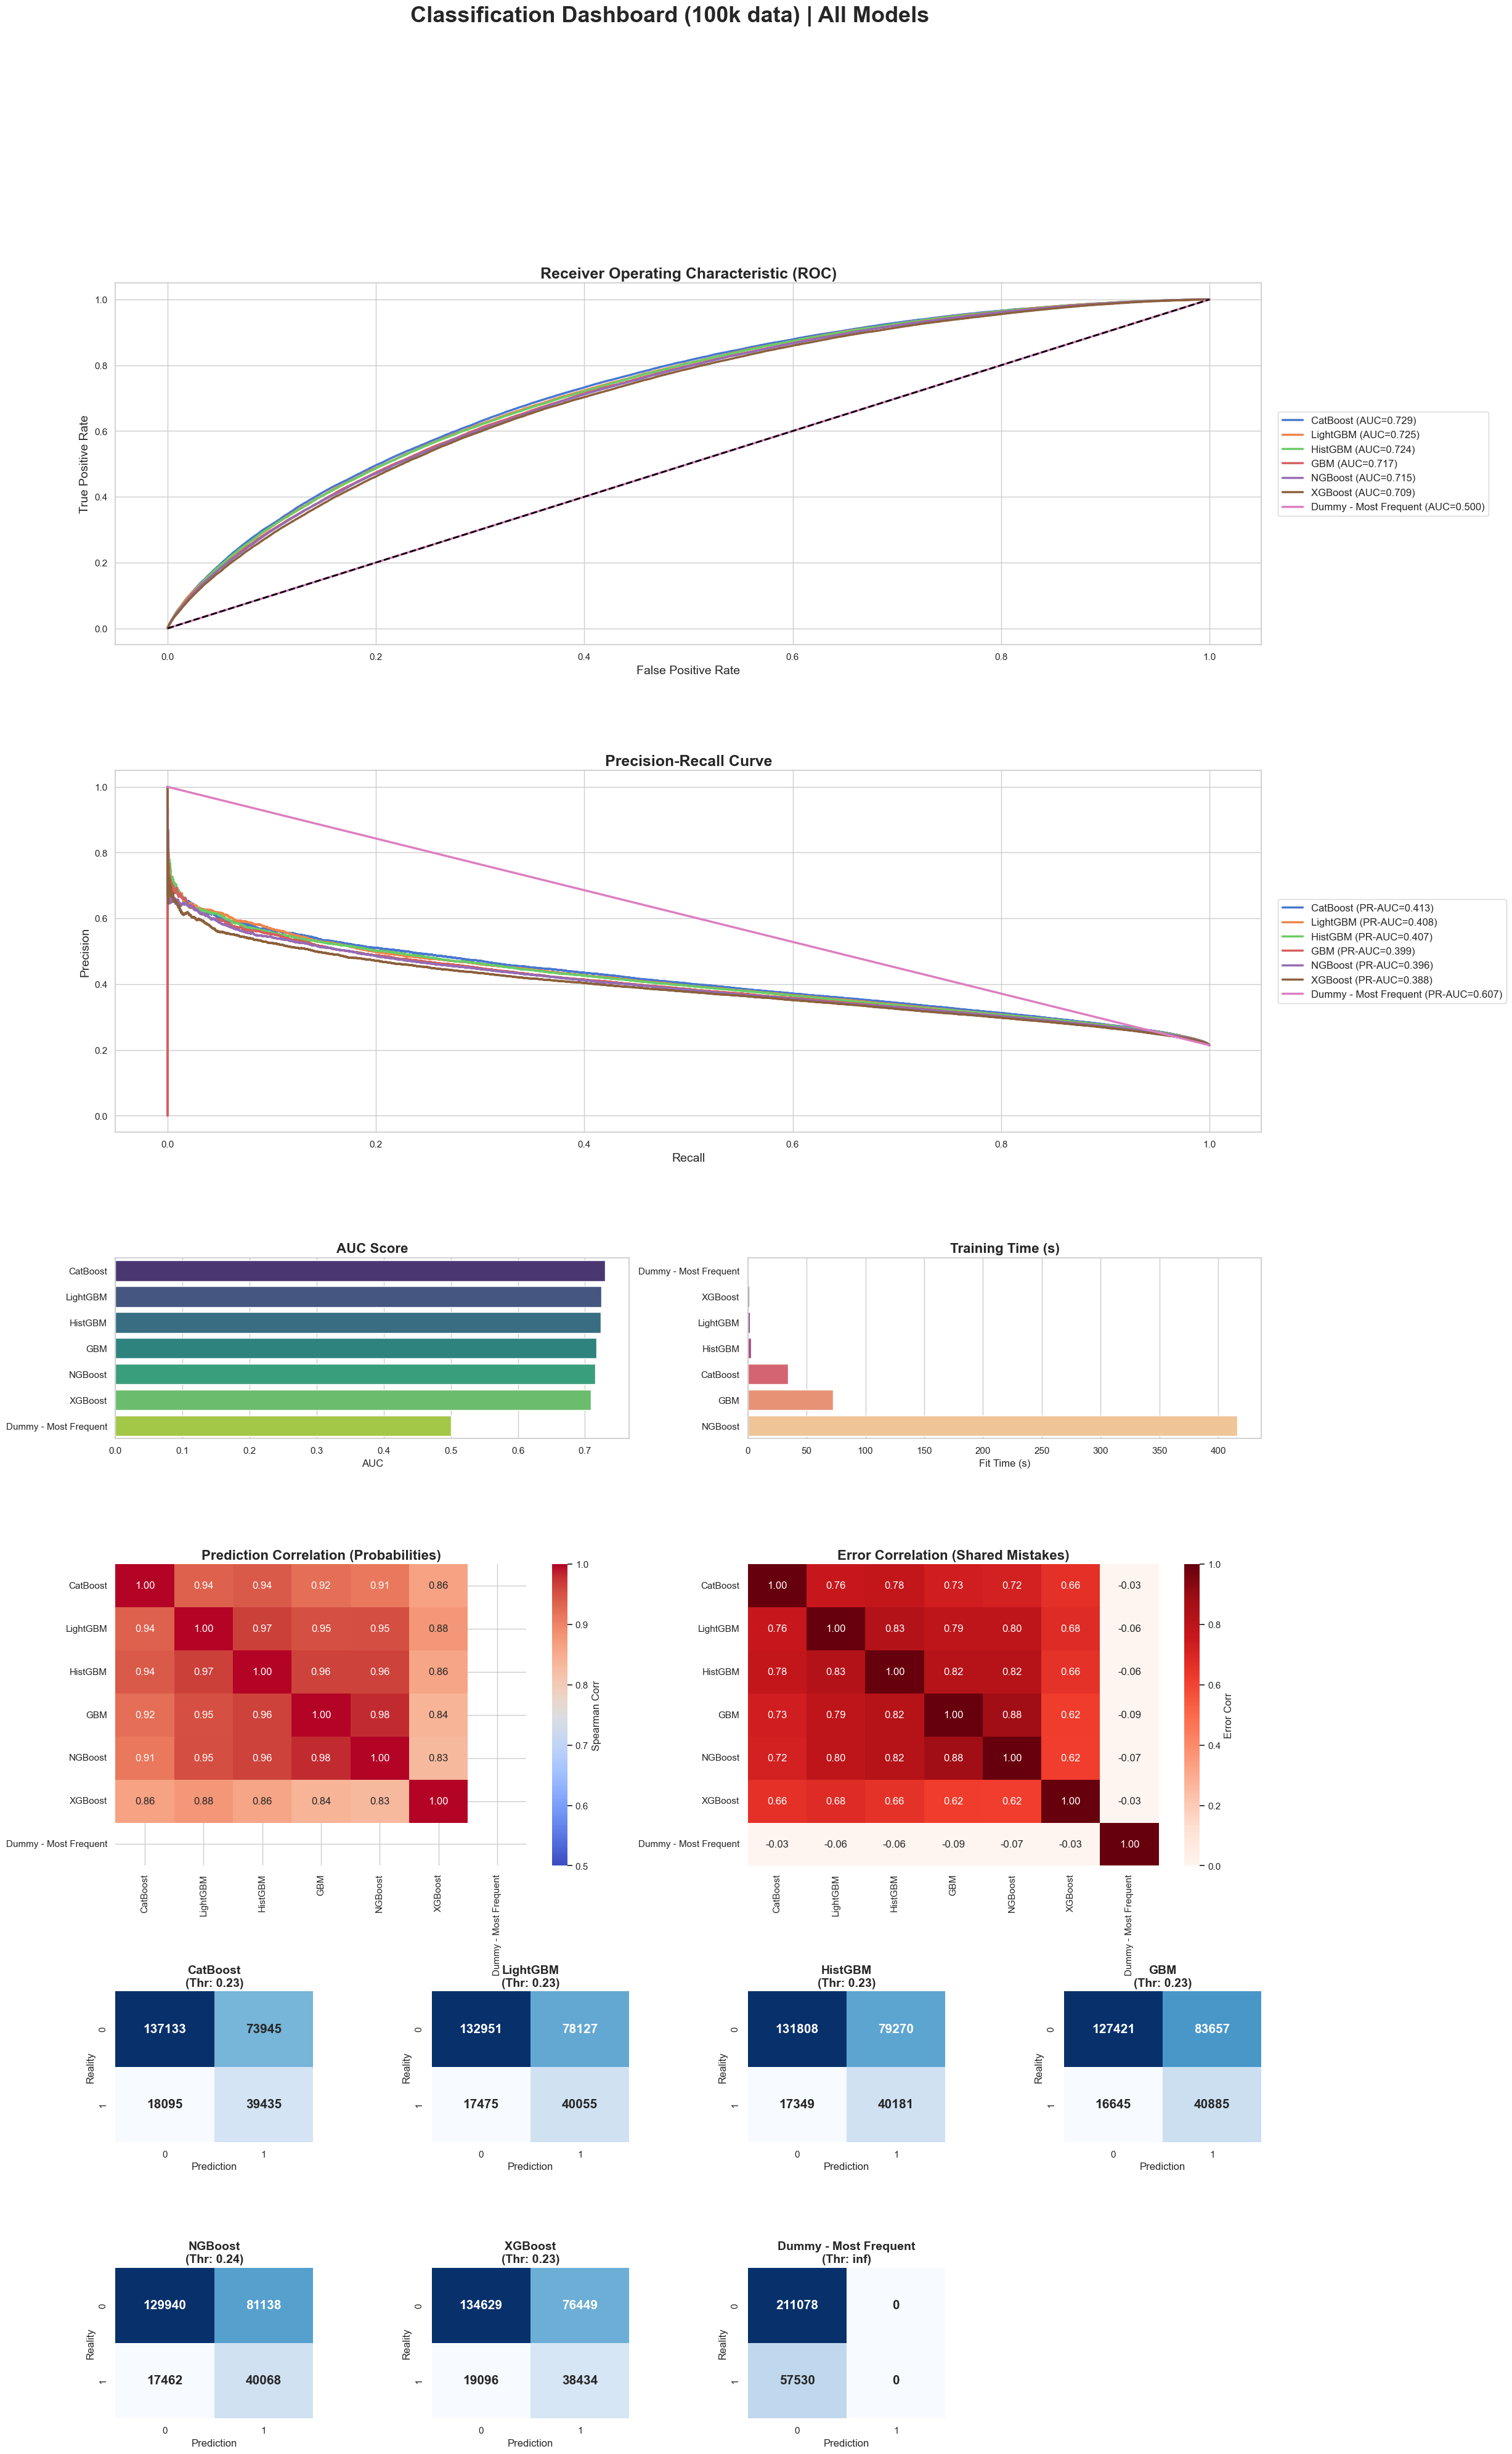

In [2]:
evaluate_classification_single_dataset("100k", "not_tuned")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")

def evaluate_classification_single_model(model_name, dataset_sizes=["1k", "10k", "100k", "full"], tuning_status="not_tuned"):
    compiled_scores = []
    preds_dict = {}
    y_true = None
    
    # Load data dynamically for all dataset sizes
    for size in dataset_sizes:
        preds_path = f"test_results/Classification/predictions/test_preds_{size}_{tuning_status}.parquet"
        scores_path = f"test_results/Classification/scores/test_scores_{size}_{tuning_status}.csv"
        
        df_preds = pd.read_parquet(preds_path).dropna()
        df_scores = pd.read_csv(scores_path)
        
        # Test targets are the same, we just extract them once
        if y_true is None:
            y_true = df_preds['true_y'].astype(int)
            
        preds_dict[size] = df_preds[model_name]
        
        # Extract score row for this specific model
        score_row = df_scores[df_scores['Model'] == model_name].copy()
        score_row['Dataset Size'] = size
        compiled_scores.append(score_row)
        
    df_all_scores = pd.concat(compiled_scores, ignore_index=True)
    
    # Ensure categorical ordering for X-axis plotting (so 'full' doesn't jump to the middle alphabetically)
    df_all_scores['Dataset Size'] = pd.Categorical(df_all_scores['Dataset Size'], categories=dataset_sizes, ordered=True)
    
    print(f"=== SCALING RESULTS: {model_name.upper()} ({tuning_status.upper()}) ===")
    display(df_all_scores[['Dataset Size', 'ROC AUC', 'PR AUC', 'Fit Time (s)', 'Pred Time (s)']])
    
    # Pre-calculate optimal thresholds, binary predictions, and errors for correlation across sizes
    df_probs = pd.DataFrame(preds_dict)
    binary_preds = {}
    optimal_thresholds = {}
    df_errors = pd.DataFrame(index=df_probs.index)
    
    for size in dataset_sizes:
        fpr, tpr, thresholds = roc_curve(y_true, df_probs[size])
        optimal_idx = np.argmax(tpr - fpr)
        opt_threshold = thresholds[optimal_idx]
        
        optimal_thresholds[size] = opt_threshold
        binary_preds[size] = (df_probs[size] >= opt_threshold).astype(int)
        
        # 1 if model made an error, 0 if correct
        df_errors[size] = (binary_preds[size] != y_true).astype(int)
    
    # Grid setup
    
    cm_cols = len(dataset_sizes)
    total_rows = 5 
    row_heights = [6, 6, 3.5, 5, 3] 
    
    fig = plt.figure(figsize=(24, 32))
    fig.suptitle(f'Model Scaling Dashboard ({model_name}) | Data: {tuning_status}', fontsize=26, fontweight='bold', y=0.98)
    
    # Create the base grid
    gs = gridspec.GridSpec(total_rows, cm_cols, figure=fig, height_ratios=row_heights, hspace=0.4, wspace=0.5)
    
    # --- ROW 1: ROC Curve (Full Width) ---
    ax1 = fig.add_subplot(gs[0, :])
    for size in dataset_sizes:
        fpr, tpr, _ = roc_curve(y_true, preds_dict[size])
        size_roc_auc = df_all_scores.loc[df_all_scores['Dataset Size'] == size, 'ROC AUC'].values[0]
        ax1.plot(fpr, tpr, lw=2.5, label=f"Data: {size} (ROC AUC={size_roc_auc:.3f})")
        
    ax1.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    ax1.set_title('Receiver Operating Characteristic (ROC) Curve by Dataset Size', fontsize=18, fontweight='bold')
    ax1.set_xlabel('False Positive Rate', fontsize=14)
    ax1.set_ylabel('True Positive Rate', fontsize=14)
    ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 2: Precision-Recall Curve (Full Width) ---
    ax2 = fig.add_subplot(gs[1, :])
    for size in dataset_sizes:
        precision, recall, _ = precision_recall_curve(y_true, preds_dict[size])
        size_pr_auc = df_all_scores.loc[df_all_scores['Dataset Size'] == size, 'PR AUC'].values[0]
        ax2.plot(recall, precision, lw=2.5, label=f"Data: {size} (PR AUC={size_pr_auc:.3f})")
        
    ax2.set_title('Precision-Recall Curve by Dataset Size', fontsize=18, fontweight='bold')
    ax2.set_xlabel('Recall', fontsize=14)
    ax2.set_ylabel('Precision', fontsize=14)
    ax2.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 3: SCALING METRICS (3 Line Plots) ---
    # Since cm_cols is usually 4, we will define a nested GridSpec for this specific row to make exactly 3 equal columns
    gs_row3 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[2, :], wspace=0.3)
    
    # Left: ROC AUC Scaling
    ax3 = fig.add_subplot(gs_row3[0, 0])
    sns.lineplot(data=df_all_scores, x='Dataset Size', y='ROC AUC', marker='o', markersize=10, 
                 color='royalblue', lw=3, ax=ax3)
    ax3.set_title('ROC AUC Scaling', fontsize=16, fontweight='bold')
    ax3.set_xlabel('Dataset Size', fontsize=12)
    ax3.set_ylabel('ROC AUC Score', fontsize=12)
    
    # Middle: PR AUC Scaling
    ax4 = fig.add_subplot(gs_row3[0, 1])
    sns.lineplot(data=df_all_scores, x='Dataset Size', y='PR AUC', marker='^', markersize=10, 
                 color='darkorange', lw=3, ax=ax4)
    ax4.set_title('PR AUC Scaling', fontsize=16, fontweight='bold')
    ax4.set_xlabel('Dataset Size', fontsize=12)
    ax4.set_ylabel('PR AUC Score', fontsize=12)

    # Right: Time Scaling
    ax5 = fig.add_subplot(gs_row3[0, 2])
    sns.lineplot(data=df_all_scores, x='Dataset Size', y='Fit Time (s)', marker='s', markersize=10, 
                 color='crimson', lw=3, ax=ax5)
    ax5.set_title('Training Time Scaling (Cost)', fontsize=16, fontweight='bold')
    ax5.set_xlabel('Dataset Size', fontsize=12)
    ax5.set_ylabel('Fit Time (s)', fontsize=12)
    
    # --- ROW 4: Correlations (Predictions vs Errors Across Dataset Sizes) ---
    ax_corr_pred = fig.add_subplot(gs[3, :cm_cols//2])
    pred_corr_matrix = df_probs.corr(method='spearman')
    sns.heatmap(pred_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, 
                cbar_kws={'label': 'Spearman Corr'}, ax=ax_corr_pred)
    ax_corr_pred.set_title('Prediction Correlation Across Sizes', fontsize=16, fontweight='bold')
    
    ax_corr_err = fig.add_subplot(gs[3, cm_cols//2:])
    err_corr_matrix = df_errors.corr()
    sns.heatmap(err_corr_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1.0, 
                cbar_kws={'label': 'Error Corr'}, ax=ax_corr_err)
    ax_corr_err.set_title('Error Correlation Across Sizes', fontsize=16, fontweight='bold')

    # --- ROW 5: Confusion Matrices (Side-by-Side) ---
    for idx, size in enumerate(dataset_sizes):
        ax_cm = fig.add_subplot(gs[4, idx])
        
        opt_threshold = optimal_thresholds[size]
        y_pred_binary = binary_preds[size]
        
        cm = confusion_matrix(y_true, y_pred_binary)
        
        sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, annot_kws={"size": 15, "weight": "bold"}, ax=ax_cm)
        ax_cm.set_title(f"Data: {size}\n(Thr: {opt_threshold:.2f})", fontsize=14, fontweight='bold')
        ax_cm.set_ylabel("Reality")
        ax_cm.set_xlabel("Prediction")

    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()

=== SCALING RESULTS: LIGHTGBM (NOT_TUNED) ===


,Dataset Size,AUC,Fit Time (s),Pred Time (s)
0,1k,0.662372,0.372227,0.459370
1,10k,0.691236,0.590750,0.327821
2,100k,0.724532,1.594538,0.362671


/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/341986084.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.96])


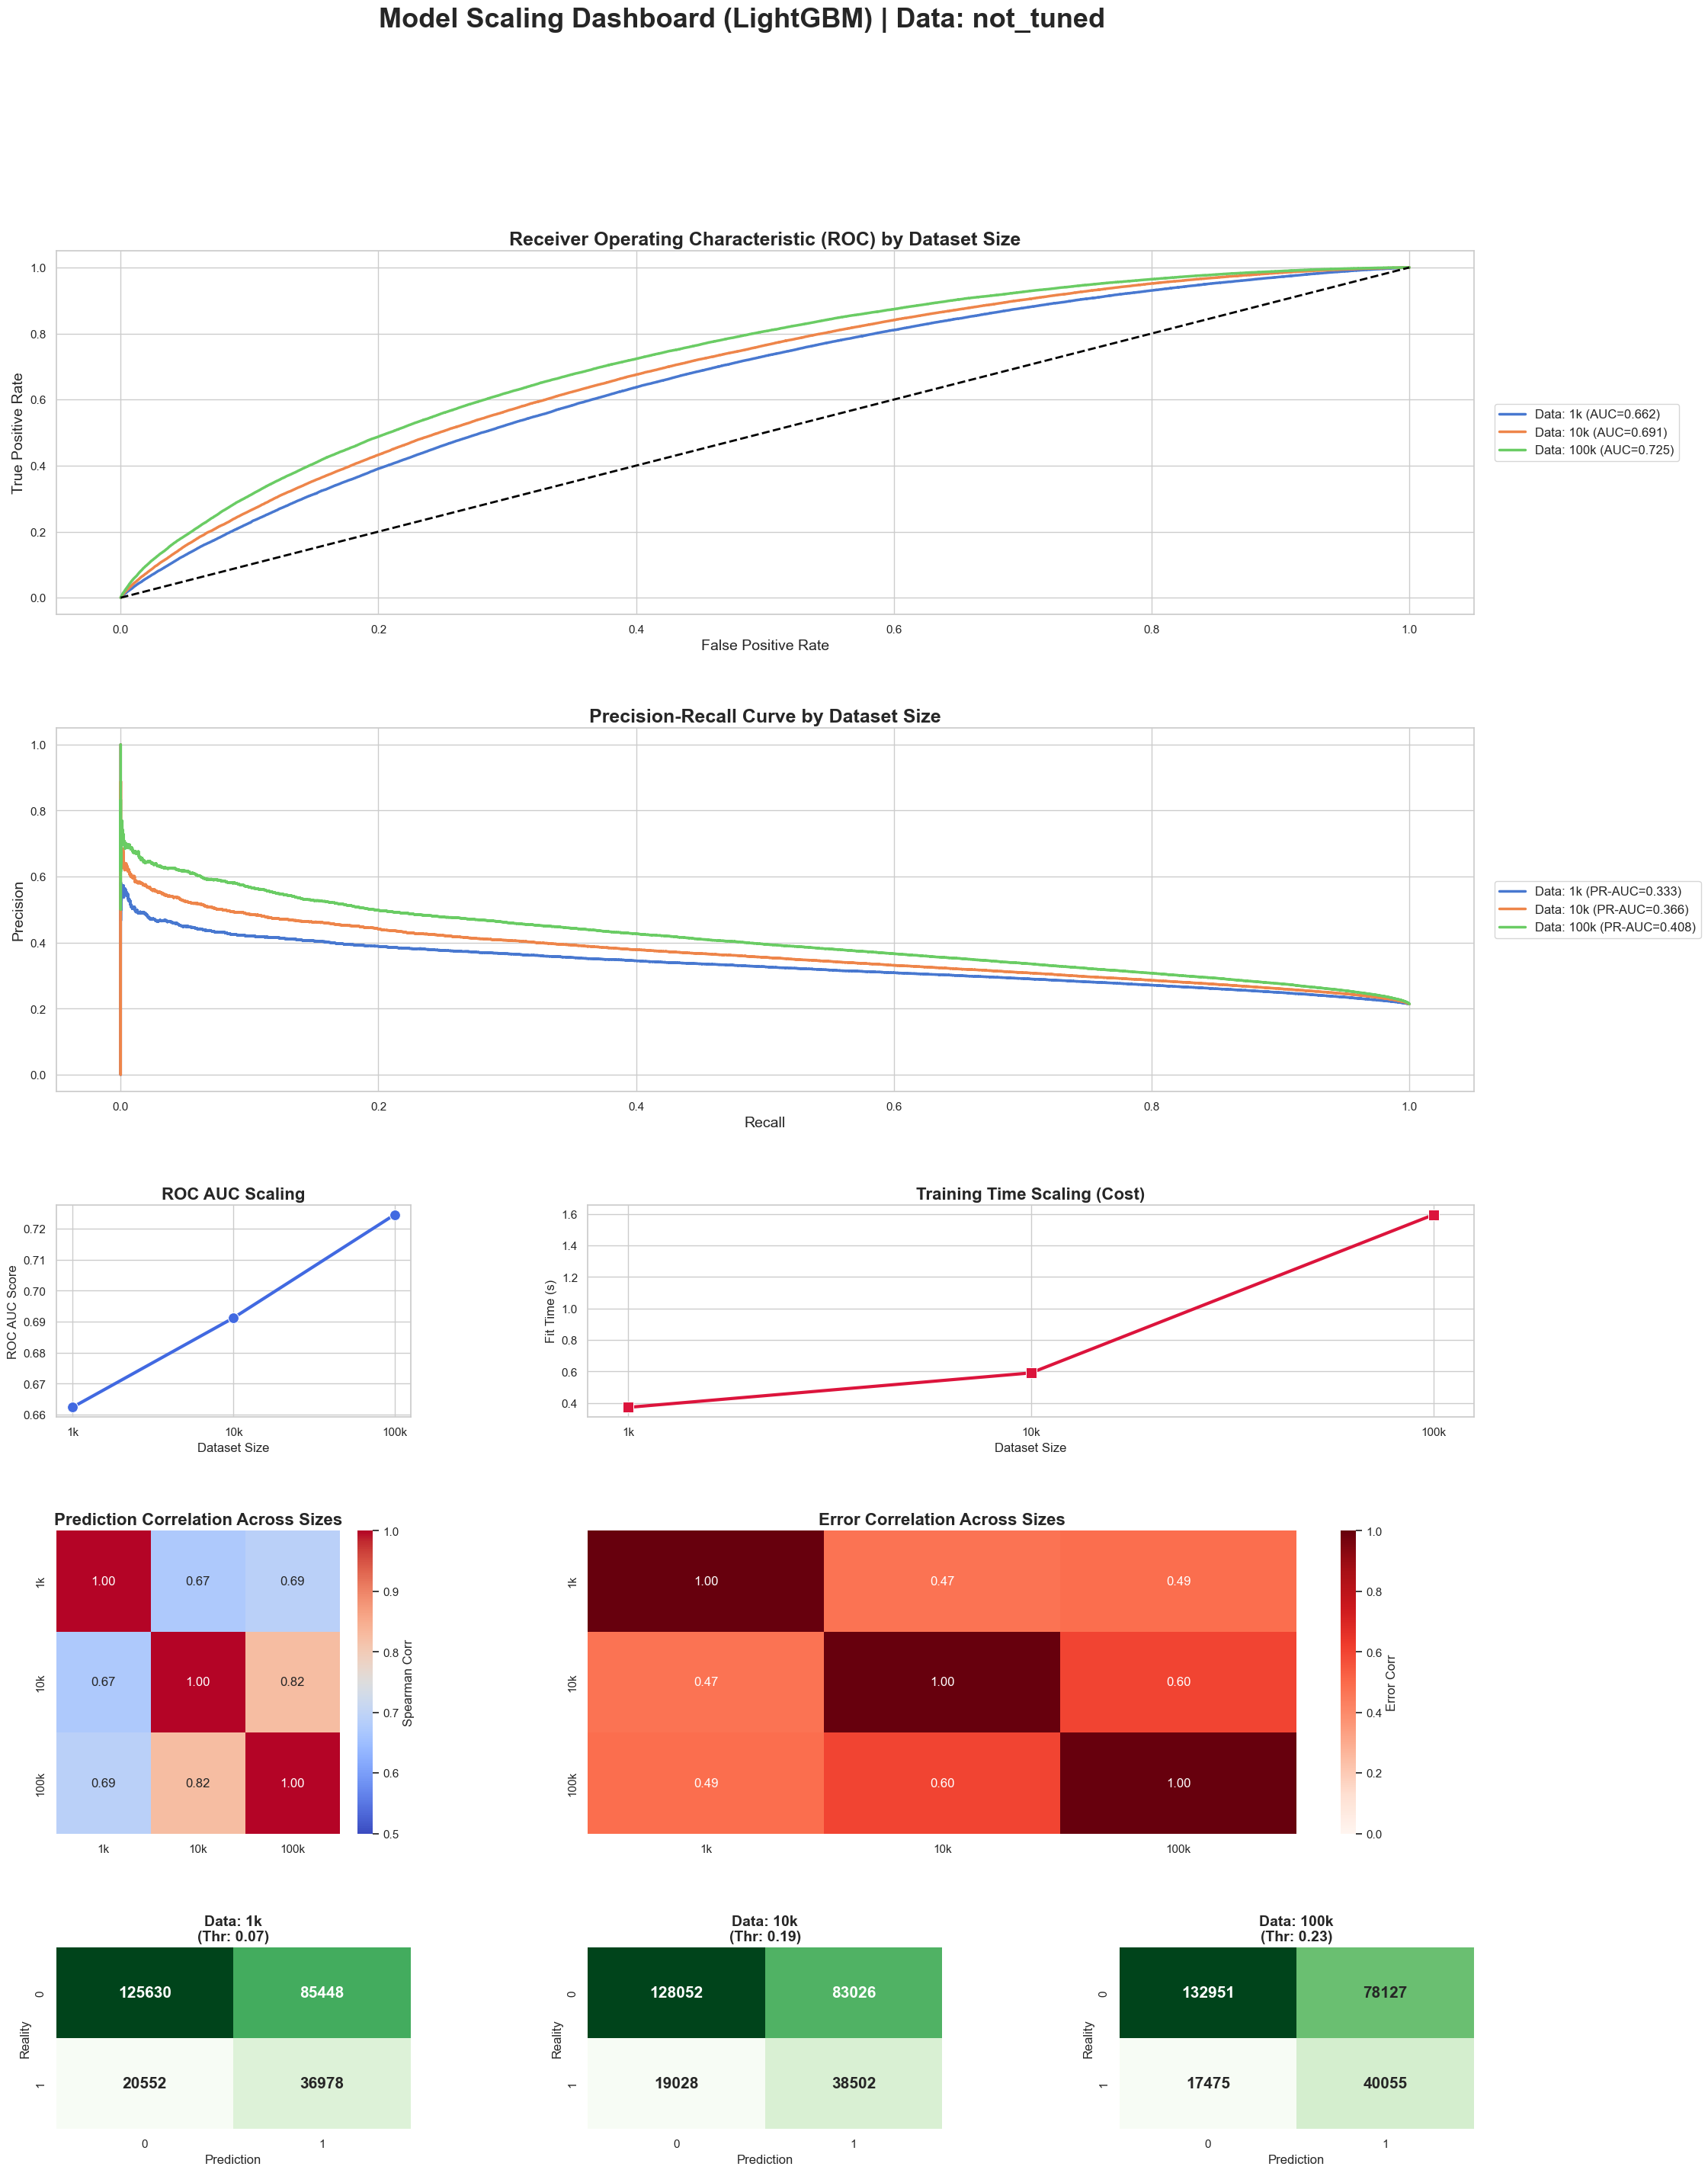

In [4]:
evaluate_classification_single_model("LightGBM", ["1k", "10k", "100k"], "not_tuned")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

# Set professional theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

def evaluate_classification_master(dataset_sizes=["1k", "10k", "100k", "full"], tuning_status="not_tuned"):
    all_compiled_scores = []
    
    # Define anchor points for detailed plots
    best_size_anchor = "100k"
    
    # 1. LOAD AND COMPILE OVERALL SCORES (Long Format)
    print(f"Loading and compiling overall scores for all sizes ({tuning_status})...")
    for size in dataset_sizes:
        scores_path = f"test_results/Classification/scores/test_scores_{size}_{tuning_status}.csv"
        try:
            df_scores = pd.read_csv(scores_path)
            df_scores['Dataset Size'] = size
            all_compiled_scores.append(df_scores)
        except FileNotFoundError:
            print(f"Warning: Score file not found for size {size}. Skipping.")

    if not all_compiled_scores:
        print("Error: No score files found. Cannot generate dashboard.")
        return

    df_overall_scores = pd.concat(all_compiled_scores, ignore_index=True)
    
    # Ensure categorical ordering for X-axis plotting
    df_overall_scores['Dataset Size'] = pd.Categorical(df_overall_scores['Dataset Size'], categories=dataset_sizes, ordered=True)
    
    # Get sorted list of unique models based on best ROC AUC performance at anchor size
    best_size_scores = df_overall_scores[df_overall_scores['Dataset Size'] == best_size_anchor].sort_values("ROC AUC", ascending=False)
    sorted_models = best_size_scores['Model'].tolist()
    top_4_models = sorted_models[:4]

    print(f"=== MASTER RESULTS SUMMARY (Anchored at {best_size_anchor}) ===")
    display(best_size_scores)
    
    # 2. LOAD ANCHOR PREDICTIONS FOR CMs AND CORRELATIONS
    print(f"Loading anchor predictions ('{best_size_anchor}') for Heatmaps and Confusion Matrices...")
    preds_path_anchor = f"test_results/Classification/predictions/test_preds_{best_size_anchor}_{tuning_status}.parquet"
    try:
        df_preds_anchor = pd.read_parquet(preds_path_anchor).dropna()
        y_true_anchor = df_preds_anchor['true_y'].astype(int)
    except FileNotFoundError:
        print(f"Error: Prediction file not found for anchor size {best_size_anchor}. Cannot plot CMs or Correlations.")
        return

    # Pre-calculate optimal thresholds, binary predictions, and errors for the anchor size
    binary_preds_anchor = {}
    optimal_thresholds_anchor = {}
    df_errors_anchor = pd.DataFrame(index=df_preds_anchor.index)
    
    for model in sorted_models:
        fpr, tpr, thresholds = roc_curve(y_true_anchor, df_preds_anchor[model])
        optimal_idx = np.argmax(tpr - fpr)
        opt_threshold = thresholds[optimal_idx]
        
        optimal_thresholds_anchor[model] = opt_threshold
        binary_preds_anchor[model] = (df_preds_anchor[model] >= opt_threshold).astype(int)
        
        # 1 if model made an error, 0 if correct
        df_errors_anchor[model] = (binary_preds_anchor[model] != y_true_anchor).astype(int)

    # 3. GRIDSETUP
    cm_cols = 4 # Top 4 models (so columns should be a multiple of 4 or just 4)
    # total rows: 3 OVERVIEW lines (ROC, PR, Time) + 1 row Bar Charts + 1 row Correlations + 1 row CMs = 6
    total_rows = 6 
    
    # Define heights: Overall lines get most space, bars/heatmaps middle, CMs standard
    row_heights = [5, 5, 5, 4, 5, 3] 
    
    # Increased figure height to fit the new PR AUC row
    fig = plt.figure(figsize=(24, 40))
    fig.suptitle(f'Master Classification Dashboard | All Models & Datasets | Data: {tuning_status}', fontsize=28, fontweight='bold', y=0.98)
    
    gs = gridspec.GridSpec(total_rows, cm_cols, figure=fig, height_ratios=row_heights, hspace=0.45, wspace=0.5)
    
    # --- ROW 1: OVERALL ROC AUC SCALING LINES (Full Width) ---
    ax1 = fig.add_subplot(gs[0, :])
    sns.lineplot(data=df_overall_scores, x='Dataset Size', y='ROC AUC', hue='Model', style='Model', 
                 marker='o', markersize=10, lw=3, palette="turbo", ax=ax1)
    
    ax1.set_title('Global Performance Scaling: ROC AUC vs. Dataset Size', fontsize=20, fontweight='bold')
    ax1.set_ylabel('ROC AUC Score', fontsize=16)
    ax1.set_xlabel('Dataset Size', fontsize=16)
    ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)

    # --- ROW 2: OVERALL PR AUC SCALING LINES (Full Width) ---
    ax2 = fig.add_subplot(gs[1, :])
    sns.lineplot(data=df_overall_scores, x='Dataset Size', y='PR AUC', hue='Model', style='Model', 
                 marker='^', markersize=10, lw=3, palette="turbo", ax=ax2, legend=False)
    
    ax2.set_title('Global Performance Scaling: PR AUC vs. Dataset Size', fontsize=20, fontweight='bold')
    ax2.set_ylabel('PR AUC Score', fontsize=16)
    ax2.set_xlabel('Dataset Size', fontsize=16)
    
    # --- ROW 3: OVERALL TIME SCALING LINES (Full Width) ---
    ax3 = fig.add_subplot(gs[2, :])
    sns.lineplot(data=df_overall_scores, x='Dataset Size', y='Fit Time (s)', hue='Model', style='Model', 
                 marker='s', markersize=10, lw=3, palette="turbo", ax=ax3, legend=False)
    
    ax3.set_title('Global Computational Cost Scaling: Training Time vs. Dataset Size', fontsize=20, fontweight='bold')
    ax3.set_ylabel('Fit Time (Seconds)', fontsize=16)
    ax3.set_xlabel('Dataset Size', fontsize=16)
    
    # --- ROW 4: SNAPSHOT AT ANCHOR SIZE (Side-by-Side Bars: ROC, PR, Time) ---
    gs_row4 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[3, :], wspace=0.3)

    # ROC AUC Snapshot
    ax4_roc = fig.add_subplot(gs_row4[0, 0])
    sns.barplot(data=best_size_scores.sort_values("ROC AUC", ascending=False), x="ROC AUC", y="Model", palette="viridis", ax=ax4_roc)
    ax4_roc.set_title(f'ROC AUC at {best_size_anchor}', fontsize=18, fontweight='bold')
    ax4_roc.set_ylabel('')

    # PR AUC Snapshot
    ax4_pr = fig.add_subplot(gs_row4[0, 1])
    sns.barplot(data=best_size_scores.sort_values("PR AUC", ascending=False), x="PR AUC", y="Model", palette="plasma", ax=ax4_pr)
    ax4_pr.set_title(f'PR AUC at {best_size_anchor}', fontsize=18, fontweight='bold')
    ax4_pr.set_ylabel('')
    
    # Time Snapshot
    ax4_time = fig.add_subplot(gs_row4[0, 2])
    sns.barplot(data=best_size_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax4_time)
    ax4_time.set_title(f'Training Time at {best_size_anchor}', fontsize=18, fontweight='bold')
    ax4_time.set_xlabel('Fit Time (s)', fontsize=12)
    ax4_time.set_ylabel('')
    
    # --- ROW 5: CORRELATIONS AT ANCHOR SIZE (Side-by-Side Heatmaps) ---
    # Prediction Correlation
    ax_corr_pred = fig.add_subplot(gs[4, :2])
    pred_corr_matrix = df_preds_anchor[sorted_models].corr(method='spearman')
    sns.heatmap(pred_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, 
                cbar_kws={'label': 'Spearman Corr'}, ax=ax_corr_pred)
    ax_corr_pred.set_title(f'Prediction Correlation (All Models at {best_size_anchor})', fontsize=16, fontweight='bold')
    
    # Error Correlation
    ax_corr_err = fig.add_subplot(gs[4, 2:])
    err_corr_matrix = df_errors_anchor[sorted_models].corr()
    sns.heatmap(err_corr_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1.0, 
                cbar_kws={'label': 'Error Corr'}, ax=ax_corr_err)
    ax_corr_err.set_title(f'Error Correlation (Shared Mistakes at {best_size_anchor})', fontsize=16, fontweight='bold')

    # --- ROW 6: TOP 4 CONFUSION MATRICES AT ANCHOR SIZE (Side-by-Side Heatmaps) ---
    for idx, model in enumerate(top_4_models):
        ax_cm = fig.add_subplot(gs[5, idx])
        
        # Pull pre-calculated binary predictions for the top 4
        y_pred_binary = binary_preds_anchor[model]
        opt_threshold = optimal_thresholds_anchor[model]
        
        cm = confusion_matrix(y_true_anchor, y_pred_binary)
        
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16, "weight": "bold"}, ax=ax_cm)
        ax_cm.set_title(f"Top {idx+1}: {model}\n({best_size_anchor} Data | Thr: {opt_threshold:.2f})", fontsize=15, fontweight='bold')
        ax_cm.set_ylabel("Reality")
        ax_cm.set_xlabel("Prediction")

    # Final adjustment to prevent overlaps with outside legends
    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()

Loading and compiling overall scores for all sizes (not_tuned)...
=== MASTER RESULTS SUMMARY (Anchored at 100k) ===


,Dataset,Model,AUC,Fit Time (s),Pred Time (s),Dataset Size
16,100k,CatBoost,0.729491,34.428379,0.307498,100k
15,100k,LightGBM,0.724532,1.594538,0.362671,100k
19,100k,HistGBM,0.723638,2.856773,0.735776,100k
18,100k,GBM,0.717134,72.609328,2.142722,100k
17,100k,NGBoost,0.715457,415.952319,12.315509,100k
14,100k,XGBoost,0.709238,1.250337,0.203816,100k
20,100k,Dummy - Most Frequent,0.500000,0.106598,0.245249,100k


Loading anchor predictions ('100k') for Heatmaps and Confusion Matrices...


/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/3887334588.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_size_scores, x="AUC", y="Model", palette="viridis", ax=ax3)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/3887334588.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_size_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax4)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/3887334588.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.96])


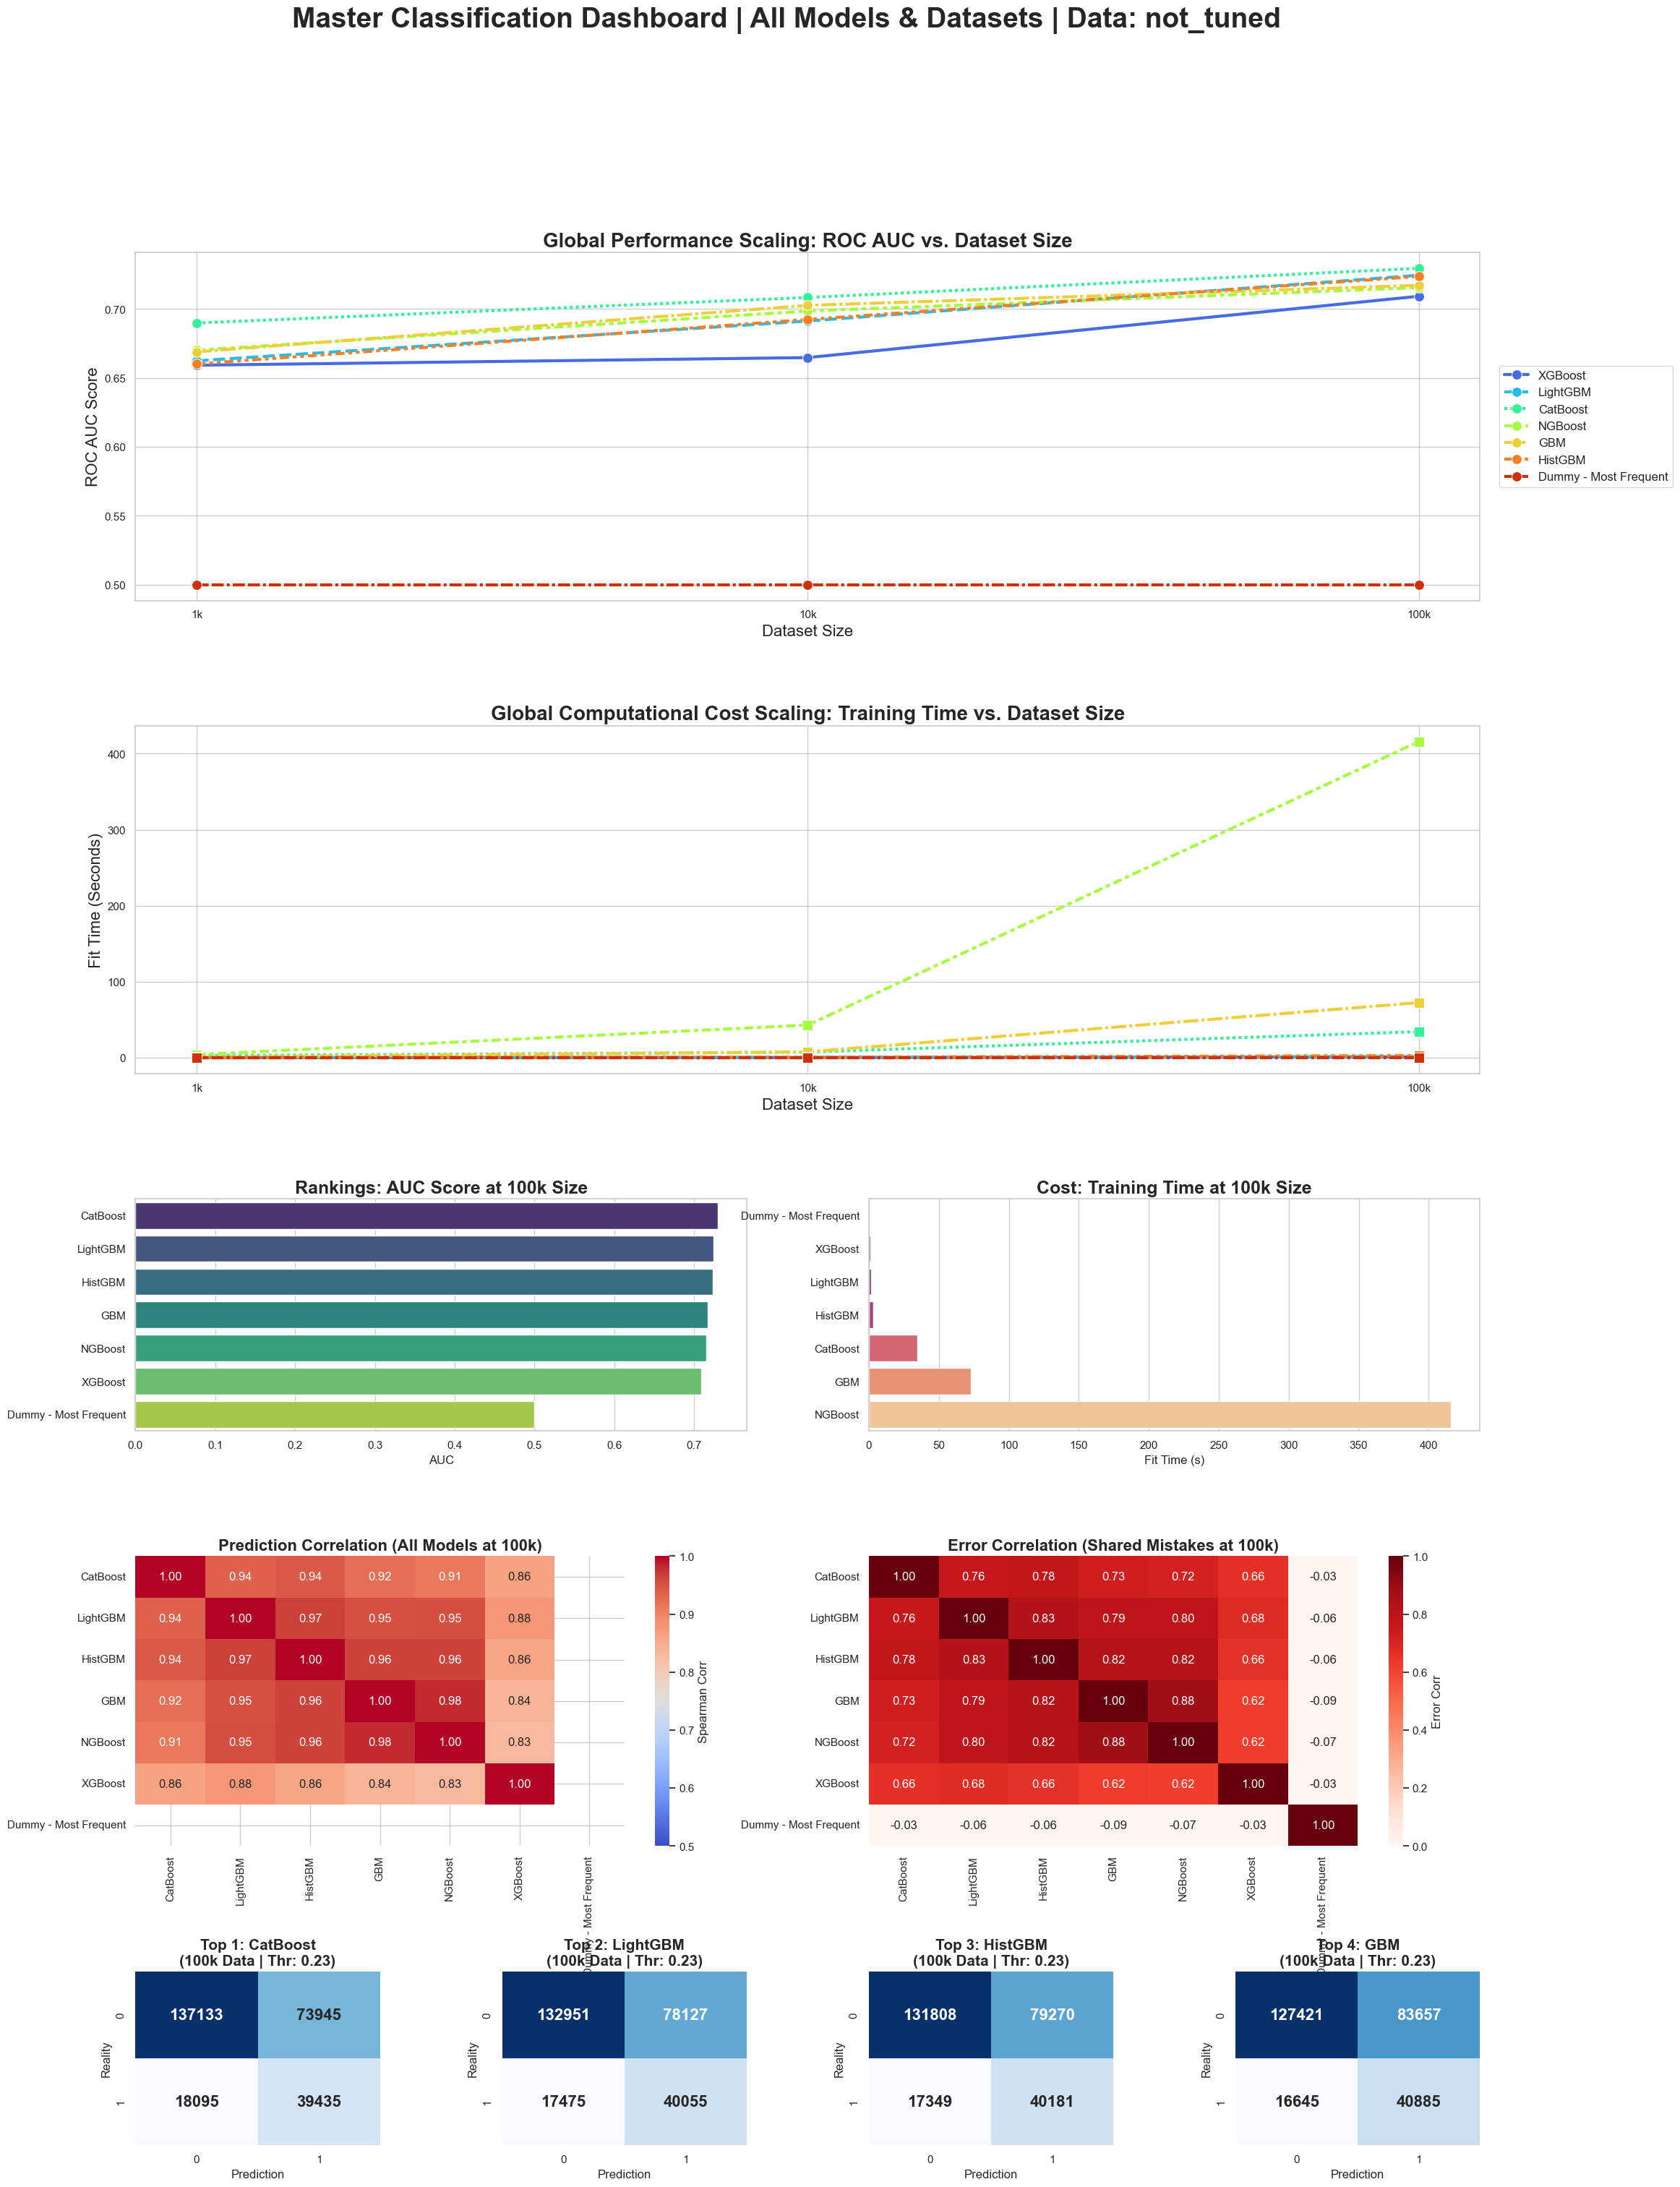

In [6]:
evaluate_classification_master(["1k", "10k", "100k"], "not_tuned")

## Regression

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Set professional theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

def evaluate_regression_single_dataset(dataset_size, tuning_status):
    preds_path = f"test_results/Regression/predictions/test_preds_{dataset_size}_{tuning_status}.parquet"
    scores_path = f"test_results/Regression/scores/test_scores_{dataset_size}_{tuning_status}.csv"
    
    # Load data and drop NaNs
    df_preds = pd.read_parquet(preds_path).dropna()
    # For regression, the main metric is RMSE, which we want as LOW as possible (ascending=True)
    df_scores = pd.read_csv(scores_path).sort_values("RMSE", ascending=True)
    
    y_true = df_preds['true_y']
    models = df_scores['Model'].tolist() # Sorted by RMSE
    
    print(f"=== REGRESSION RESULTS: {dataset_size.upper()} | {tuning_status.upper()} ===")
    display(df_scores)
    
    # Pre-calculate residuals (errors) for correlation analysis
    df_residuals = pd.DataFrame(index=df_preds.index)
    for model in models:
        df_residuals[model] = y_true - df_preds[model]
        
    sc_cols = 4 # Number of scatter plots per row
    sc_rows = int(np.ceil(len(models) / sc_cols))
    
    # Row 0: Residuals KDE, Row 1: Error Boxplots, Row 2: Bar charts, Row 3: Correlations, Row 4+: Scatters
    total_rows = 4 + sc_rows 
    
    # Added height (5) for the correlation heatmaps row
    row_heights = [6, 6, 3, 5] + [3.5] * sc_rows
    
    # Increased base figure height
    fig = plt.figure(figsize=(24, 35 + 6 * sc_rows))
    fig.suptitle(f'Regression Dashboard ({dataset_size} data) | All Models', fontsize=26, fontweight='bold', y=0.98)
    
    gs = gridspec.GridSpec(total_rows, sc_cols, figure=fig, height_ratios=row_heights, hspace=0.5, wspace=0.5)
    
    # --- ROW 1: Distribution of Residuals (Full Width) ---
    ax1 = fig.add_subplot(gs[0, :])
    for model in models:
        sns.kdeplot(df_residuals[model], lw=2.5, label=model, ax=ax1)
        
    ax1.axvline(0, color='black', lw=2, linestyle='--') # Ideal center (zero error)
    ax1.set_title('Distribution of Residuals (Errors: Actual - Predicted)', fontsize=18, fontweight='bold')
    ax1.set_xlabel('Residual Value', fontsize=14)
    ax1.set_ylabel('Density', fontsize=14)
    ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 2: Absolute Errors Boxplot (Full Width) ---
    ax2 = fig.add_subplot(gs[1, :])
    # Prepare data for boxplots (calculate absolute errors)
    err_dict = {model: np.abs(df_residuals[model]) for model in models}
    df_err = pd.DataFrame(err_dict).melt(var_name="Model", value_name="Absolute Error")
    
    # showfliers=False ensures extreme outliers don't ruin chart readability
    sns.boxplot(data=df_err, x="Absolute Error", y="Model", palette="viridis", ax=ax2, showfliers=False)
    ax2.set_title('Absolute Error Distribution by Model (Lower & Narrower is Better)', fontsize=18, fontweight='bold')
    ax2.set_xlabel('Absolute Error', fontsize=14)
    ax2.set_ylabel('')
    
    # --- ROW 3: Bar Charts (Side by Side) ---
    ax3 = fig.add_subplot(gs[2, :2])
    sns.barplot(data=df_scores, x="RMSE", y="Model", palette="mako", ax=ax3)
    ax3.set_title('RMSE Score (Lower is Better)', fontsize=16, fontweight='bold')
    ax3.set_ylabel('')
    
    ax4 = fig.add_subplot(gs[2, 2:])
    sns.barplot(data=df_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax4)
    ax4.set_title('Training Time (s)', fontsize=16, fontweight='bold')
    ax4.set_xlabel('Fit Time (s)', fontsize=12)
    ax4.set_ylabel('')
    
    # --- ROW 4: Correlations (Predictions vs Residuals) ---
    # Prediction Correlation (Pearson is standard for continuous regression outputs)
    ax_corr_pred = fig.add_subplot(gs[3, :2])
    pred_corr_matrix = df_preds[models].corr(method='pearson')
    sns.heatmap(pred_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, 
                cbar_kws={'label': 'Pearson Corr'}, ax=ax_corr_pred)
    ax_corr_pred.set_title('Prediction Correlation (Raw Output)', fontsize=16, fontweight='bold')
    
    # Residual Correlation (Pearson on directional errors)
    ax_corr_err = fig.add_subplot(gs[3, 2:])
    err_corr_matrix = df_residuals[models].corr(method='pearson')
    # vmin can be left at default or set to 0. Usually models correlate positively, but negative is possible.
    sns.heatmap(err_corr_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1.0, 
                cbar_kws={'label': 'Residual Corr'}, ax=ax_corr_err)
    ax_corr_err.set_title('Residual Correlation (Shared Directional Errors)', fontsize=16, fontweight='bold')

    # --- ROW 5+: Actual vs Predicted Scatter Plots for ALL models ---
    for idx, model in enumerate(models):
        row = 4 + (idx // sc_cols) # Shifted down by 1 row
        col = idx % sc_cols
        ax_sc = fig.add_subplot(gs[row, col])
        
        y_pred = df_preds[model]
        rmse_val = df_scores.loc[df_scores['Model'] == model, 'RMSE'].values[0]
        r2_val = df_scores.loc[df_scores['Model'] == model, 'R2'].values[0]
        
        # Scatter plot of points
        ax_sc.scatter(y_true, y_pred, alpha=0.3, color='dodgerblue', edgecolors='none')
        
        # Draw the ideal line (y = x)
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax_sc.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
        
        ax_sc.set_title(f"{model}\n(RMSE: {rmse_val:.2f} | R2: {r2_val:.3f})", fontsize=14, fontweight='bold')
        ax_sc.set_ylabel("Predicted Value")
        ax_sc.set_xlabel("Actual Value")

    # Reserve space on the right for the legend
    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()

=== REGRESSION RESULTS: 10K | NOT_TUNED ===


,Dataset,Model,RMSE,R2,MAE,MAPE,Fit Time (s),Pred Time (s)
3,10k,NGBoost,0.359907,0.023571,0.249641,5.905795e+10,75.641931,22.274966
2,10k,CatBoost,0.360329,0.021280,0.249037,9.235742e+10,4.681586,0.442855
4,10k,GBM,0.360356,0.021138,0.249655,6.474612e+10,7.257874,1.410014
5,10k,HistGBM,0.361786,0.013352,0.247775,8.047953e+10,0.871673,0.718347
6,10k,PGBM,0.361951,0.012451,0.247473,8.460189e+10,1.917139,0.578703
1,10k,LightGBM,0.362031,0.012013,0.248470,8.394833e+10,0.463957,0.268946
7,10k,Dummy - Most Frequent,0.365265,-0.005714,0.261587,5.002489e+10,0.014198,0.350977
0,10k,XGBoost,0.377267,-0.072896,0.261333,1.692373e+11,0.404224,0.130553


/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/224729717.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_err, x="Absolute Error", y="Model", palette="viridis", ax=ax2, showfliers=False)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/224729717.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_scores, x="RMSE", y="Model", palette="mako", ax=ax3)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/224729717.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_score

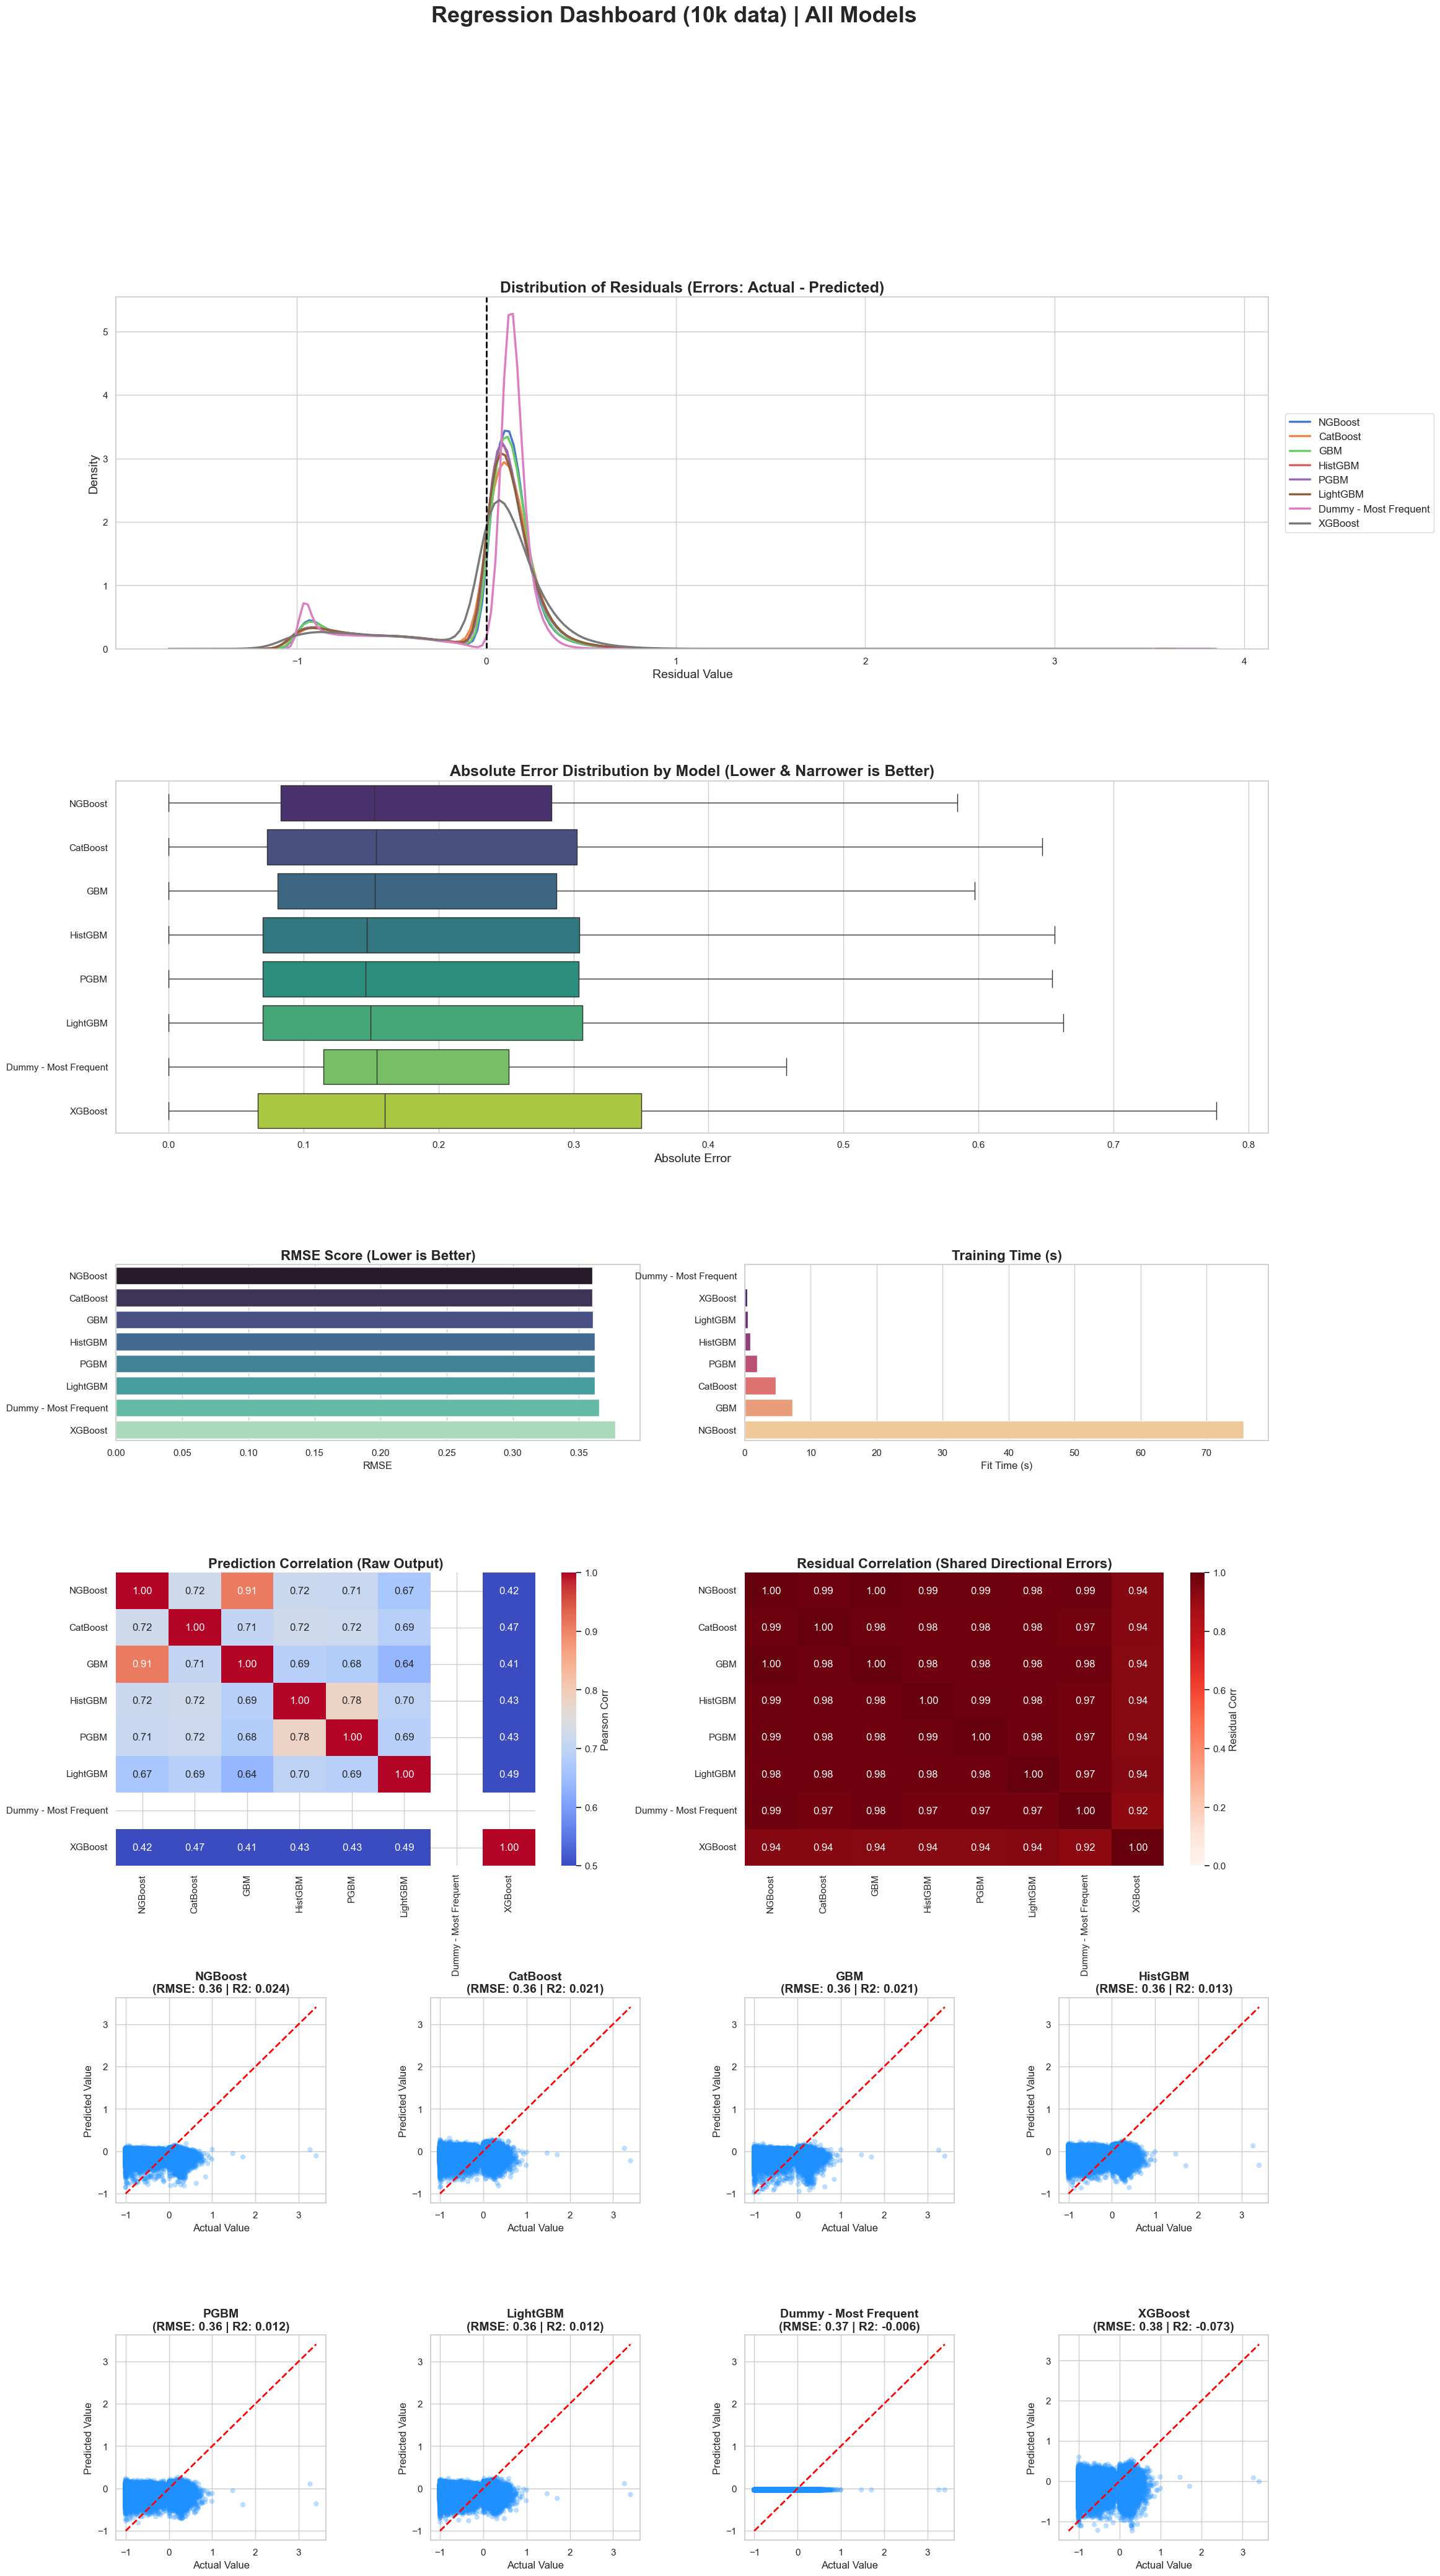

In [8]:
evaluate_regression_single_dataset("10k", "not_tuned")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Set professional theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

def evaluate_regression_single_model(model_name, dataset_sizes=["1k", "10k", "100k", "full"], tuning_status="not_tuned"):
    compiled_scores = []
    preds_dict = {}
    df_residuals = pd.DataFrame()
    y_true = None
    
    # Load data dynamically for all dataset sizes
    for size in dataset_sizes:
        preds_path = f"test_results/Regression/predictions/test_preds_{size}_{tuning_status}.parquet"
        scores_path = f"test_results/Regression/scores/test_scores_{size}_{tuning_status}.csv"
        
        df_preds = pd.read_parquet(preds_path).dropna()
        df_scores = pd.read_csv(scores_path)
        
        # Test targets are the same, we just extract them once
        if y_true is None:
            y_true = df_preds['true_y']
            
        preds_dict[size] = df_preds[model_name]
        
        # Calculate residuals for this specific dataset size
        df_residuals[size] = y_true - df_preds[model_name]
        
        # Extract score row for this specific model
        score_row = df_scores[df_scores['Model'] == model_name].copy()
        score_row['Dataset Size'] = size
        compiled_scores.append(score_row)
        
    df_all_scores = pd.concat(compiled_scores, ignore_index=True)
    
    # Ensure categorical ordering for X-axis plotting
    df_all_scores['Dataset Size'] = pd.Categorical(df_all_scores['Dataset Size'], categories=dataset_sizes, ordered=True)
    
    print(f"=== SCALING RESULTS: {model_name.upper()} ({tuning_status.upper()}) ===")
    # Display relevant regression metrics
    display(df_all_scores[['Dataset Size', 'RMSE', 'R2', 'MAE', 'Fit Time (s)', 'Pred Time (s)']])
    
    df_preds_sizes = pd.DataFrame(preds_dict)
    
    # Grid setup
    sc_cols = len(dataset_sizes)
    # total_rows = 5: Residuals KDE, Boxplots, Scaling Lines, Correlations, Scatter Plots
    total_rows = 5 
    
    # Heights: Curves at top, metrics in middle, heatmaps, scatters at bottom
    row_heights = [6, 5, 3.5, 5, 4] 
    
    fig = plt.figure(figsize=(24, 34))
    fig.suptitle(f'Model Scaling Dashboard ({model_name}) | Regression | Data: {tuning_status}', fontsize=26, fontweight='bold', y=0.98)
    
    gs = gridspec.GridSpec(total_rows, sc_cols, figure=fig, height_ratios=row_heights, hspace=0.4, wspace=0.5)
    
    # --- ROW 1: Distribution of Residuals (Full Width) ---
    ax1 = fig.add_subplot(gs[0, :])
    for size in dataset_sizes:
        sns.kdeplot(df_residuals[size], lw=2.5, label=f"Data: {size}", ax=ax1)
        
    ax1.axvline(0, color='black', lw=2, linestyle='--')
    ax1.set_title('Distribution of Residuals by Dataset Size', fontsize=18, fontweight='bold')
    ax1.set_xlabel('Residual Value', fontsize=14)
    ax1.set_ylabel('Density', fontsize=14)
    ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 2: Absolute Errors Boxplot (Full Width) ---
    ax2 = fig.add_subplot(gs[1, :])
    err_dict = {size: np.abs(df_residuals[size]) for size in dataset_sizes}
    df_err = pd.DataFrame(err_dict).melt(var_name="Dataset Size", value_name="Absolute Error")
    
    sns.boxplot(data=df_err, x="Absolute Error", y="Dataset Size", palette="viridis", ax=ax2, showfliers=False)
    ax2.set_title('Absolute Error Distribution by Dataset Size (Lower & Narrower is Better)', fontsize=18, fontweight='bold')
    ax2.set_xlabel('Absolute Error', fontsize=14)
    ax2.set_ylabel('')
    
    # --- ROW 3: SCALING METRICS (Side-by-Side Line Plots) ---
    # Left: RMSE Scaling
    ax3 = fig.add_subplot(gs[2, :sc_cols//2])
    sns.lineplot(data=df_all_scores, x='Dataset Size', y='RMSE', marker='o', markersize=10, 
                 color='royalblue', lw=3, ax=ax3)
    ax3.set_title('RMSE Scaling (Lower is Better)', fontsize=16, fontweight='bold')
    ax3.set_xlabel('Dataset Size', fontsize=12)
    ax3.set_ylabel('RMSE', fontsize=12)
    
    # Right: Time Scaling
    ax4 = fig.add_subplot(gs[2, sc_cols//2:])
    sns.lineplot(data=df_all_scores, x='Dataset Size', y='Fit Time (s)', marker='s', markersize=10, 
                 color='crimson', lw=3, ax=ax4)
    ax4.set_title('Training Time Scaling (Cost)', fontsize=16, fontweight='bold')
    ax4.set_xlabel('Dataset Size', fontsize=12)
    ax4.set_ylabel('Fit Time (s)', fontsize=12)
    
    # --- ROW 4: Correlations (Predictions vs Residuals Across Sizes) ---
    # Prediction Correlation
    ax_corr_pred = fig.add_subplot(gs[3, :sc_cols//2])
    pred_corr_matrix = df_preds_sizes.corr(method='pearson')
    sns.heatmap(pred_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, 
                cbar_kws={'label': 'Pearson Corr'}, ax=ax_corr_pred)
    ax_corr_pred.set_title('Prediction Correlation Across Sizes', fontsize=16, fontweight='bold')
    
    # Residual Correlation
    ax_corr_err = fig.add_subplot(gs[3, sc_cols//2:])
    err_corr_matrix = df_residuals.corr(method='pearson')
    sns.heatmap(err_corr_matrix, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1.0, 
                cbar_kws={'label': 'Residual Corr'}, ax=ax_corr_err)
    ax_corr_err.set_title('Residual Correlation Across Sizes', fontsize=16, fontweight='bold')

    # --- ROW 5: Actual vs Predicted Scatter Plots (Side-by-Side) ---
    for idx, size in enumerate(dataset_sizes):
        ax_sc = fig.add_subplot(gs[4, idx])
        
        y_pred = df_preds_sizes[size]
        rmse_val = df_all_scores.loc[df_all_scores['Dataset Size'] == size, 'RMSE'].values[0]
        r2_val = df_all_scores.loc[df_all_scores['Dataset Size'] == size, 'R2'].values[0]
        
        # Scatter plot
        ax_sc.scatter(y_true, y_pred, alpha=0.3, color='dodgerblue', edgecolors='none')
        
        # Ideal line
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax_sc.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
        
        ax_sc.set_title(f"Data: {size}\n(RMSE: {rmse_val:.2f} | R2: {r2_val:.3f})", fontsize=14, fontweight='bold')
        ax_sc.set_ylabel("Predicted Value")
        ax_sc.set_xlabel("Actual Value")

    # Reserve 15% margin on the right for the outside legends
    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()

=== SCALING RESULTS: XGBOOST (NOT_TUNED) ===


,Dataset Size,RMSE,R2,MAE,Fit Time (s),Pred Time (s)
0,1k,0.388365,-0.136943,0.275853,0.316629,0.160174
1,10k,0.377267,-0.072896,0.261333,0.404224,0.130553


/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/439688748.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_err, x="Absolute Error", y="Dataset Size", palette="viridis", ax=ax2, showfliers=False)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/439688748.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.96])


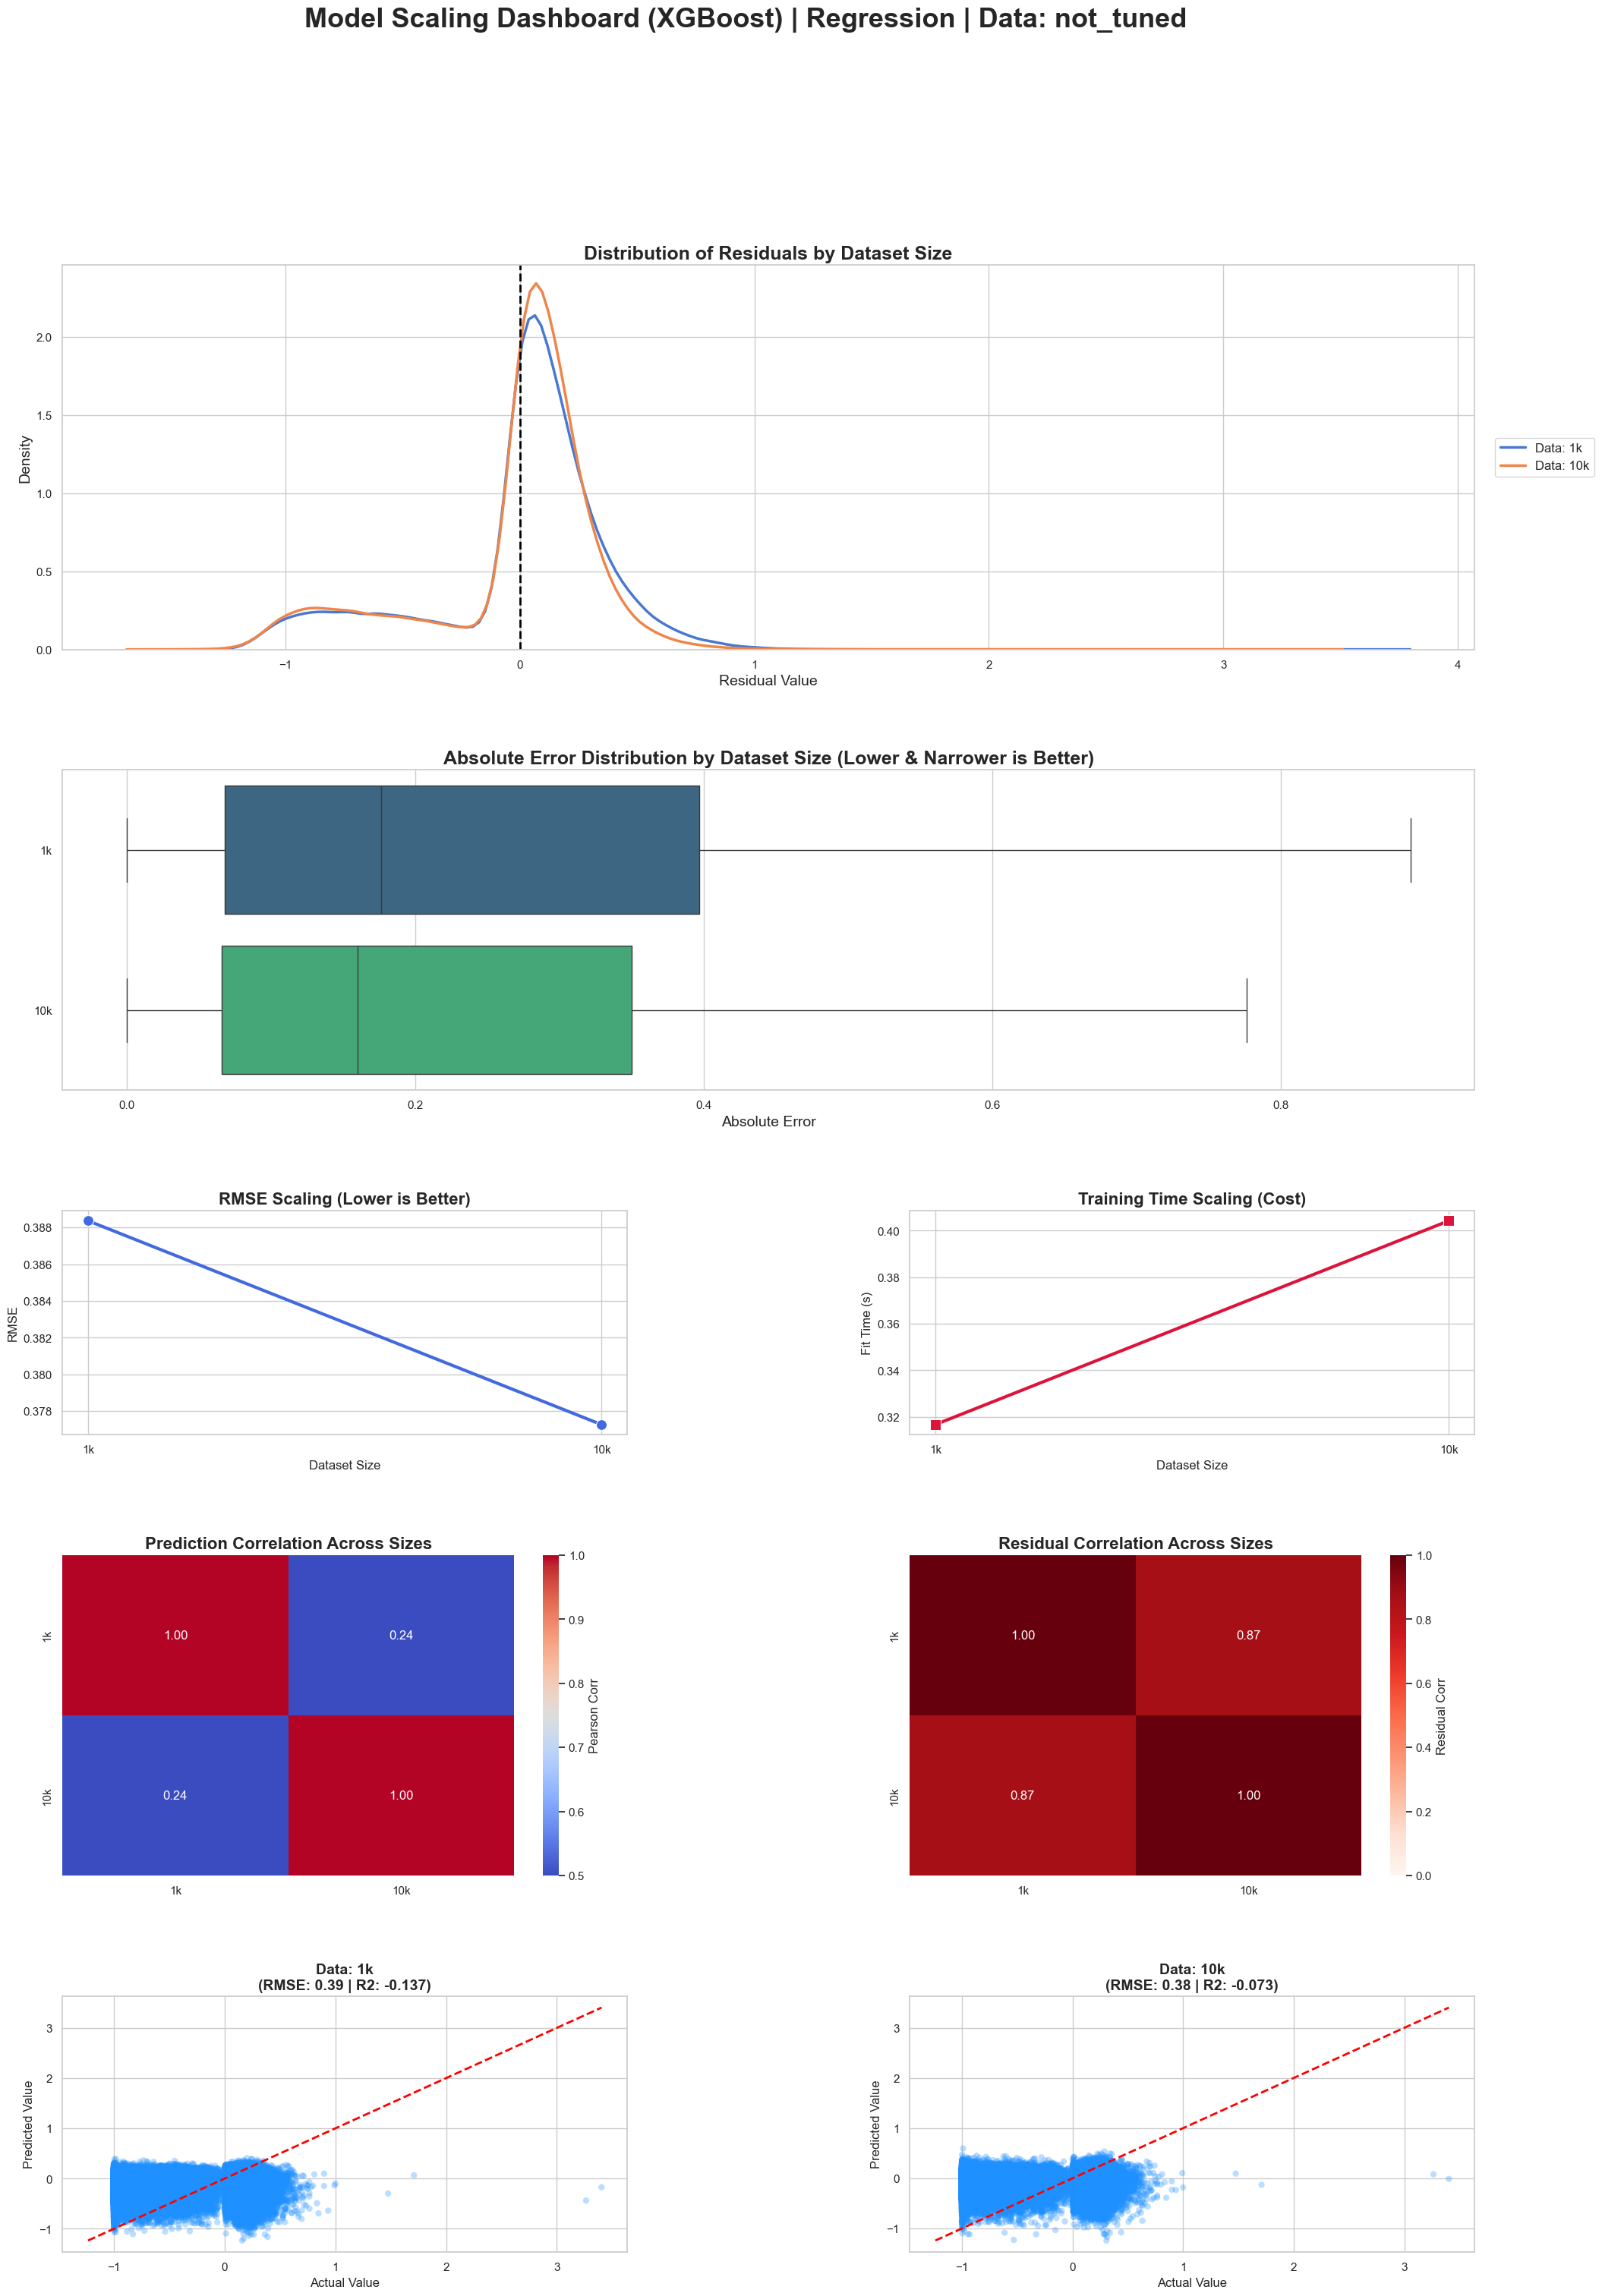

In [11]:
evaluate_regression_single_model("XGBoost", ["1k", "10k"], "not_tuned")

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Set professional theme for all plots
sns.set_theme(style="whitegrid", palette="muted")

def evaluate_regression_master(dataset_sizes=["1k", "10k", "100k", "full"], tuning_status="not_tuned"):
    all_compiled_scores = []
    
    # Define anchor points for detailed plots
    best_size_anchor = "10k"
    
    # 1. LOAD AND COMPILE OVERALL SCORES (Long Format)
    print(f"Loading and compiling overall scores for all sizes ({tuning_status})...")
    for size in dataset_sizes:
        scores_path = f"test_results/Regression/scores/test_scores_{size}_{tuning_status}.csv"
        try:
            df_scores = pd.read_csv(scores_path)
            df_scores['Dataset Size'] = size
            all_compiled_scores.append(df_scores)
        except FileNotFoundError:
            print(f"Warning: Score file not found for size {size}. Skipping.")

    if not all_compiled_scores:
        print("Error: No score files found. Cannot generate dashboard.")
        return

    df_overall_scores = pd.concat(all_compiled_scores, ignore_index=True)
    
    # Ensure categorical ordering for X-axis plotting
    df_overall_scores['Dataset Size'] = pd.Categorical(df_overall_scores['Dataset Size'], categories=dataset_sizes, ordered=True)
    
    # Get sorted list of unique models based on best performance at anchor size (RMSE is lower = better)
    best_size_scores = df_overall_scores[df_overall_scores['Dataset Size'] == best_size_anchor].sort_values("RMSE", ascending=True)
    sorted_models = best_size_scores['Model'].tolist()
    top_4_models = sorted_models[:4]

    print(f"=== MASTER RESULTS SUMMARY (Anchored at {best_size_anchor}) ===")
    display(best_size_scores[['Model', 'RMSE', 'R2', 'MAE', 'Fit Time (s)']])
    
    # 2. LOAD ANCHOR PREDICTIONS FOR CORRELATIONS AND SCATTER PLOTS
    print(f"Loading anchor predictions ('{best_size_anchor}') for Heatmaps and Scatter Plots...")
    preds_path_anchor = f"test_results/Regression/predictions/test_preds_{best_size_anchor}_{tuning_status}.parquet"
    try:
        df_preds_anchor = pd.read_parquet(preds_path_anchor).dropna()
        y_true_anchor = df_preds_anchor['true_y']
    except FileNotFoundError:
        print(f"Error: Prediction file not found for anchor size {best_size_anchor}. Cannot plot visuals.")
        return

    # Pre-calculate residuals (errors) for the anchor size
    df_residuals_anchor = pd.DataFrame(index=df_preds_anchor.index)
    for model in sorted_models:
        df_residuals_anchor[model] = y_true_anchor - df_preds_anchor[model]

    # 3. GRIDSETUP
    sc_cols = 4 # Top 4 models
    # total rows: 3 OVERVIEW rows + 1 row for Correlations + 1 row for Scatters
    total_rows = 5 
    
    # Define heights: Overall lines get most space, bars/heatmaps middle, Scatters standard
    row_heights = [6, 6, 4, 5, 4] 
    
    # Increased figure height to fit everything comfortably
    fig = plt.figure(figsize=(24, 34))
    fig.suptitle(f'Master Regression Dashboard | All Models & Datasets | Data: {tuning_status}', fontsize=28, fontweight='bold', y=0.98)
    
    gs = gridspec.GridSpec(total_rows, sc_cols, figure=fig, height_ratios=row_heights, hspace=0.45, wspace=0.5)
    
    # --- ROW 1: OVERALL RMSE SCALING LINES (Full Width) ---
    ax1 = fig.add_subplot(gs[0, :])
    sns.lineplot(data=df_overall_scores, x='Dataset Size', y='RMSE', hue='Model', style='Model', 
                 marker='o', markersize=10, lw=3, palette="turbo", ax=ax1)
    
    ax1.set_title('Global Performance Scaling: RMSE vs. Dataset Size (Lower is Better)', fontsize=20, fontweight='bold')
    ax1.set_ylabel('RMSE', fontsize=16)
    ax1.set_xlabel('Dataset Size', fontsize=16)
    ax1.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12)
    
    # --- ROW 2: OVERALL TIME SCALING LINES (Full Width) ---
    ax2 = fig.add_subplot(gs[1, :])
    sns.lineplot(data=df_overall_scores, x='Dataset Size', y='Fit Time (s)', hue='Model', style='Model', 
                 marker='s', markersize=10, lw=3, palette="turbo", ax=ax2, legend=False)
    
    ax2.set_title('Global Computational Cost Scaling: Training Time vs. Dataset Size', fontsize=20, fontweight='bold')
    ax2.set_ylabel('Fit Time (Seconds)', fontsize=16)
    ax2.set_xlabel('Dataset Size', fontsize=16)
    
    # --- ROW 3: SNAPSHOT AT ANCHOR SIZE (Side-by-Side Bars) ---
    # RMSE Snapshot
    ax3 = fig.add_subplot(gs[2, :2])
    sns.barplot(data=best_size_scores, x="RMSE", y="Model", palette="mako", ax=ax3)
    ax3.set_title(f'Rankings: RMSE Score at {best_size_anchor} Size', fontsize=18, fontweight='bold')
    ax3.set_ylabel('')
    
    # Time Snapshot
    ax4 = fig.add_subplot(gs[2, 2:])
    sns.barplot(data=best_size_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax4)
    ax4.set_title(f'Cost: Training Time at {best_size_anchor} Size', fontsize=18, fontweight='bold')
    ax4.set_xlabel('Fit Time (s)', fontsize=12)
    ax4.set_ylabel('')
    
    # --- ROW 4: CORRELATIONS AT ANCHOR SIZE (Side-by-Side Heatmaps) ---
    # Prediction Correlation
    ax_corr_pred = fig.add_subplot(gs[3, :2])
    pred_corr_matrix = df_preds_anchor[sorted_models].corr(method='pearson')
    sns.heatmap(pred_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0.5, vmax=1.0, 
                cbar_kws={'label': 'Pearson Corr'}, ax=ax_corr_pred)
    ax_corr_pred.set_title(f'Prediction Correlation (All Models at {best_size_anchor})', fontsize=16, fontweight='bold')
    
    # Residual Correlation
    ax_corr_err = fig.add_subplot(gs[3, 2:])
    err_corr_matrix = df_residuals_anchor[sorted_models].corr(method='pearson')
    # Using coolwarm with vmin=-1.0 to capture potential negative correlations in regression errors
    sns.heatmap(err_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1.0, vmax=1.0, 
                cbar_kws={'label': 'Residual Corr'}, ax=ax_corr_err)
    ax_corr_err.set_title(f'Residual Correlation (Shared Errors at {best_size_anchor})', fontsize=16, fontweight='bold')

    # --- ROW 5: TOP 4 ACTUAL VS PREDICTED SCATTER PLOTS AT ANCHOR SIZE ---
    for idx, model in enumerate(top_4_models):
        ax_sc = fig.add_subplot(gs[4, idx])
        
        y_pred = df_preds_anchor[model]
        rmse_val = best_size_scores.loc[best_size_scores['Model'] == model, 'RMSE'].values[0]
        r2_val = best_size_scores.loc[best_size_scores['Model'] == model, 'R2'].values[0]
        
        # Scatter plot
        ax_sc.scatter(y_true_anchor, y_pred, alpha=0.3, color='dodgerblue', edgecolors='none')
        
        # Ideal line
        min_val = min(y_true_anchor.min(), y_pred.min())
        max_val = max(y_true_anchor.max(), y_pred.max())
        ax_sc.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
        
        ax_sc.set_title(f"Top {idx+1}: {model}\n(RMSE: {rmse_val:.2f} | R2: {r2_val:.3f})", fontsize=15, fontweight='bold')
        ax_sc.set_ylabel("Predicted Value")
        ax_sc.set_xlabel("Actual Value")

    # Final adjustment to prevent overlaps with outside legends
    plt.tight_layout(rect=[0, 0, 0.85, 0.96])
    plt.show()

Loading and compiling overall scores for all sizes (not_tuned)...
=== MASTER RESULTS SUMMARY (Anchored at 10k) ===


,Model,RMSE,R2,MAE,Fit Time (s)
11,NGBoost,0.359907,0.023571,0.249641,75.641931
10,CatBoost,0.360329,0.021280,0.249037,4.681586
12,GBM,0.360356,0.021138,0.249655,7.257874
13,HistGBM,0.361786,0.013352,0.247775,0.871673
14,PGBM,0.361951,0.012451,0.247473,1.917139
9,LightGBM,0.362031,0.012013,0.248470,0.463957
15,Dummy - Most Frequent,0.365265,-0.005714,0.261587,0.014198
8,XGBoost,0.377267,-0.072896,0.261333,0.404224


Loading anchor predictions ('10k') for Heatmaps and Scatter Plots...


/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/881758025.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_size_scores, x="RMSE", y="Model", palette="mako", ax=ax3)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/881758025.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_size_scores.sort_values("Fit Time (s)"), x="Fit Time (s)", y="Model", palette="magma", ax=ax4)
/var/folders/pt/4rypzgx161xbyqfj39t1nrqh0000gn/T/ipykernel_28828/881758025.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.96])


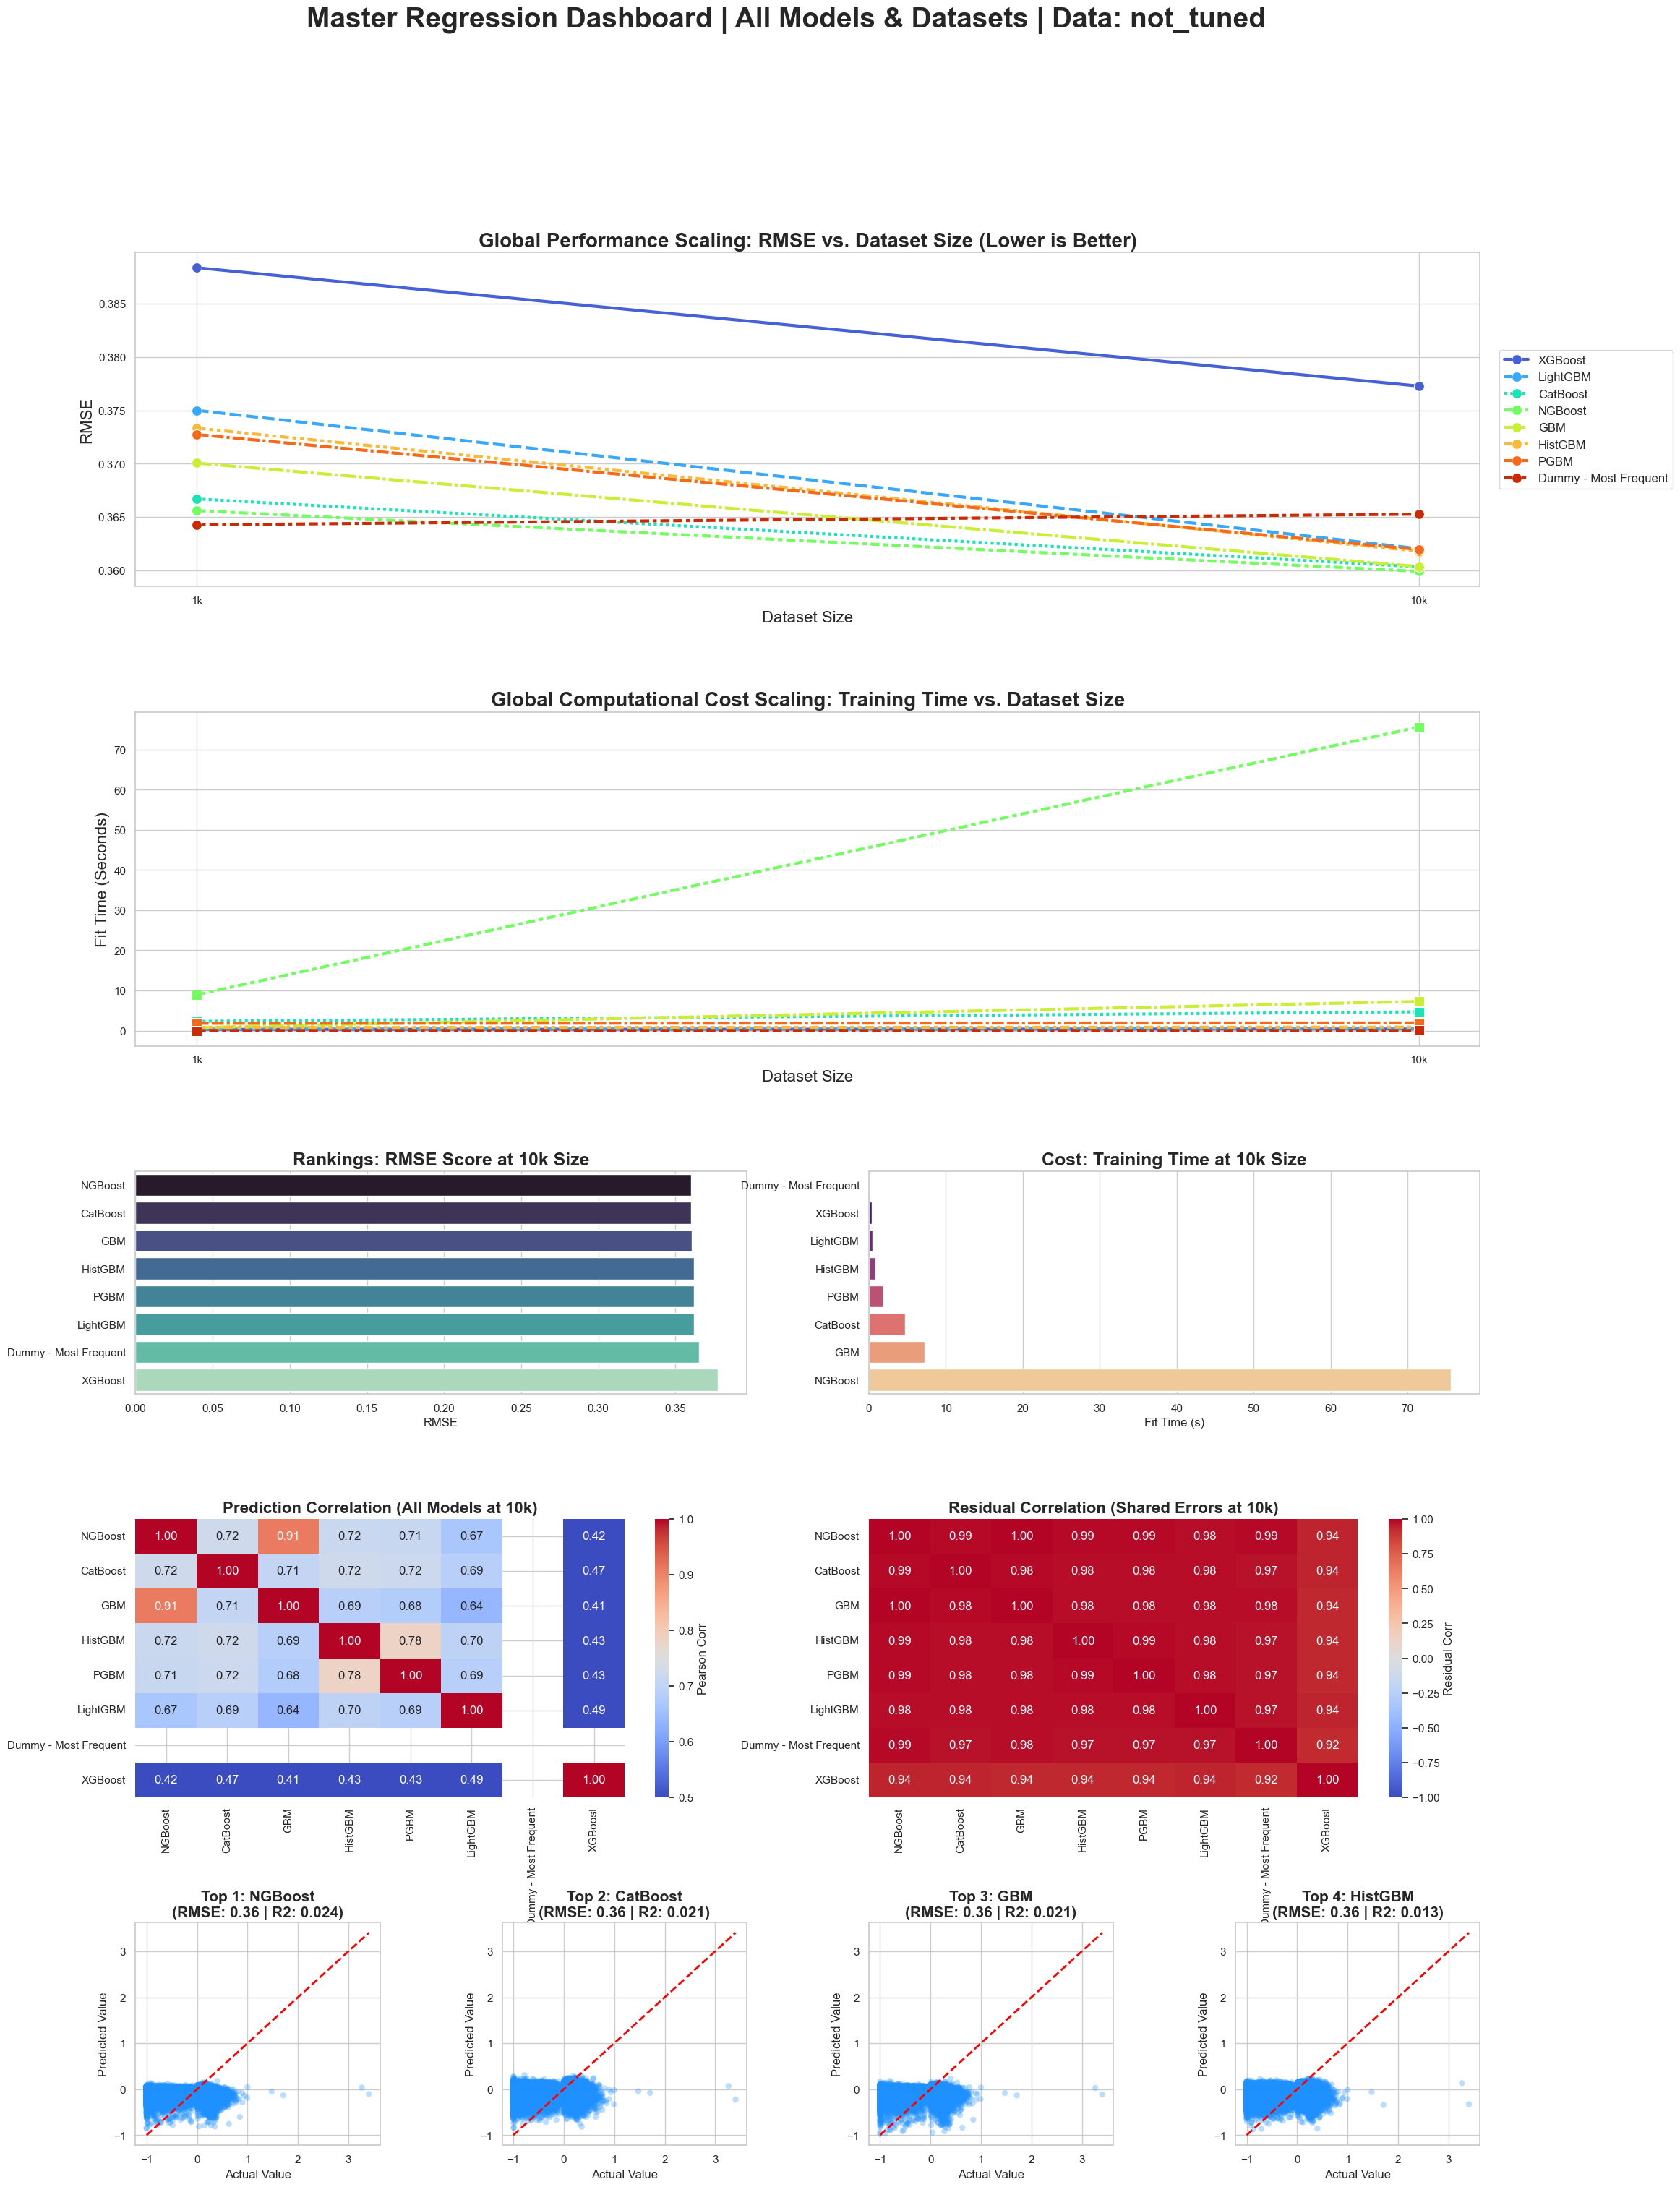

In [15]:
evaluate_regression_master(["1k", "10k"], "not_tuned")